# QuantOpt: Portfolio Optimization — Visualization and Documentation Notebook

This notebook provides a complete, self-contained walkthrough of the QuantOpt library.
All data is generated synthetically via Geometric Brownian Motion (GBM); no network
access or external data files are required.

---

## Section 0 — Setup and Synthetic Data Generation

All asset price paths are simulated under the standard GBM diffusion:

$$dS_i = \mu_i S_i \, dt + \sigma_i S_i \, dW_i$$

In discrete time (Euler-Maruyama), the log-price increment is:

$$S_i(t+1) = S_i(t) \cdot \exp\!\left(\left(\mu_i - \tfrac{1}{2}\sigma_i^2\right)dt + \sigma_i\sqrt{dt}\, Z_i\right), \quad Z_i \sim \mathcal{N}(0,1)$$

Cross-asset correlation is introduced by drawing the innovation vector $\mathbf{Z}$ from
$\mathbf{Z} = \mathbf{L}\boldsymbol{\xi}$, where $\boldsymbol{\xi} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
and $\mathbf{L}$ is the lower Cholesky factor of the correlation matrix $\mathbf{C}$.

The correlation matrix is itself generated via a three-factor model:
$\mathbf{C} = \text{normalize}(\mathbf{L}_f \mathbf{L}_f^\top + \mathbf{D})$,
which produces a realistic block-correlation structure without any asset having
unit correlation to the latent factors.

**Simulation parameters:**
- $N = 10$ assets, $T = 1{,}260$ trading days (approximately 5 years)
- $\mu_i^{\text{annual}} \in [0.07, 0.15]$, $\sigma_i^{\text{daily}} \in [0.011, 0.022]$
- Implied annualized volatilities: $\sigma_i^{\text{annual}} = \sigma_i^{\text{daily}}\sqrt{252} \in [17\%, 35\%]$

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import probplot, norm as scipy_norm
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = sns.color_palette("muted")

Path("../docs/figures").mkdir(parents=True, exist_ok=True)

# ── Simulation parameters ────────────────────────────────────────────────────
rng = np.random.default_rng(42)
N_ASSETS = 10
T_DAYS   = 1260
dt       = 1 / 252

TICKERS = [
    "ASSET_A", "ASSET_B", "ASSET_C", "ASSET_D", "ASSET_E",
    "ASSET_F", "ASSET_G", "ASSET_H", "ASSET_I", "ASSET_J",
]

mu_annual    = np.array([0.10, 0.12, 0.08, 0.15, 0.09,
                          0.11, 0.13, 0.07, 0.14, 0.10])
sigma_daily  = np.array([0.015, 0.018, 0.012, 0.022, 0.014,
                          0.016, 0.019, 0.011, 0.021, 0.015])

# ── Correlation matrix via three-factor structure ────────────────────────────
L_fac  = rng.standard_normal((N_ASSETS, 3)) * 0.3
C_raw  = L_fac @ L_fac.T
np.fill_diagonal(C_raw, 1.0)
D_fill = 1.0 - np.diag(C_raw) + 1e-6
np.fill_diagonal(C_raw, np.diag(C_raw) + D_fill)
std_inv = 1.0 / np.sqrt(np.diag(C_raw))
corr_matrix = C_raw * np.outer(std_inv, std_inv)
np.fill_diagonal(corr_matrix, 1.0)

chol = np.linalg.cholesky(corr_matrix)

# ── Price simulation ─────────────────────────────────────────────────────────
dates       = pd.bdate_range(start="2019-01-02", periods=T_DAYS)
log_returns = np.zeros((T_DAYS, N_ASSETS))
for t in range(T_DAYS):
    Z            = rng.standard_normal(N_ASSETS)
    Z_corr       = chol @ Z
    log_returns[t] = (
        mu_annual / 252 - 0.5 * sigma_daily ** 2
    ) + sigma_daily * Z_corr

prices  = pd.DataFrame(
    100 * np.exp(np.cumsum(log_returns, axis=0)),
    index=dates, columns=TICKERS,
)
returns = pd.DataFrame(log_returns, index=dates, columns=TICKERS)

print(f"Prices  shape : {prices.shape}")
print(f"Returns shape : {returns.shape}")
print(f"Date range    : {dates[0].date()} → {dates[-1].date()}")
prices.describe().round(4)

Prices  shape : (1260, 10)
Returns shape : (1260, 10)
Date range    : 2019-01-02 → 2023-10-31


,ASSET_A,ASSET_B,ASSET_C,ASSET_D,ASSET_E,ASSET_F,ASSET_G,ASSET_H,ASSET_I,ASSET_J
count,1260.0000,1260.0000,1260.0000,1260.0000,1260.0000,1260.0000,1260.0000,1260.0000,1260.0000,1260.0000
mean,98.0380,153.6289,96.0138,73.2099,100.2020,81.5957,124.9167,109.0476,143.0596,133.8137
std,16.4544,44.4258,7.8322,18.7801,26.3412,18.2442,25.5201,17.6754,31.5803,53.2346
min,66.1501,80.8843,80.7084,43.4235,65.0721,48.3917,69.7979,79.5149,80.0499,79.8472
25%,82.8176,113.7226,89.8003,59.2765,76.3375,64.6127,107.5951,94.6551,126.9308,97.5679
50%,98.0979,156.2506,94.8076,70.9436,95.0983,83.9729,118.2676,105.9509,137.8705,108.3574
75%,110.3198,190.6774,101.7973,80.1785,123.0407,95.4447,140.5074,122.9727,158.9605,156.4501
max,140.4090,265.6661,121.2538,136.8015,163.2942,125.1914,195.9557,149.8080,235.7947,295.7509


---
## Section 1 — Price Series and Return Distributions

Log returns are used throughout because they are time-additive:
$r^{\log}_{[0,T]} = \sum_{t=1}^{T} r^{\log}_t$,
and their distribution under GBM is exactly Gaussian in continuous time.
Empirically, equity log-return distributions exhibit excess kurtosis
(fat tails) and negative skewness not captured by the Gaussian assumption;
this is a known limitation of the GBM framework, discussed further in
the Limitations section.

**Figure 1** presents four diagnostic panels: the normalized price paths,
the simulated correlation matrix, the marginal return densities overlaid
against a standard normal reference, and the cross-sectional ordering of
annualized volatility.

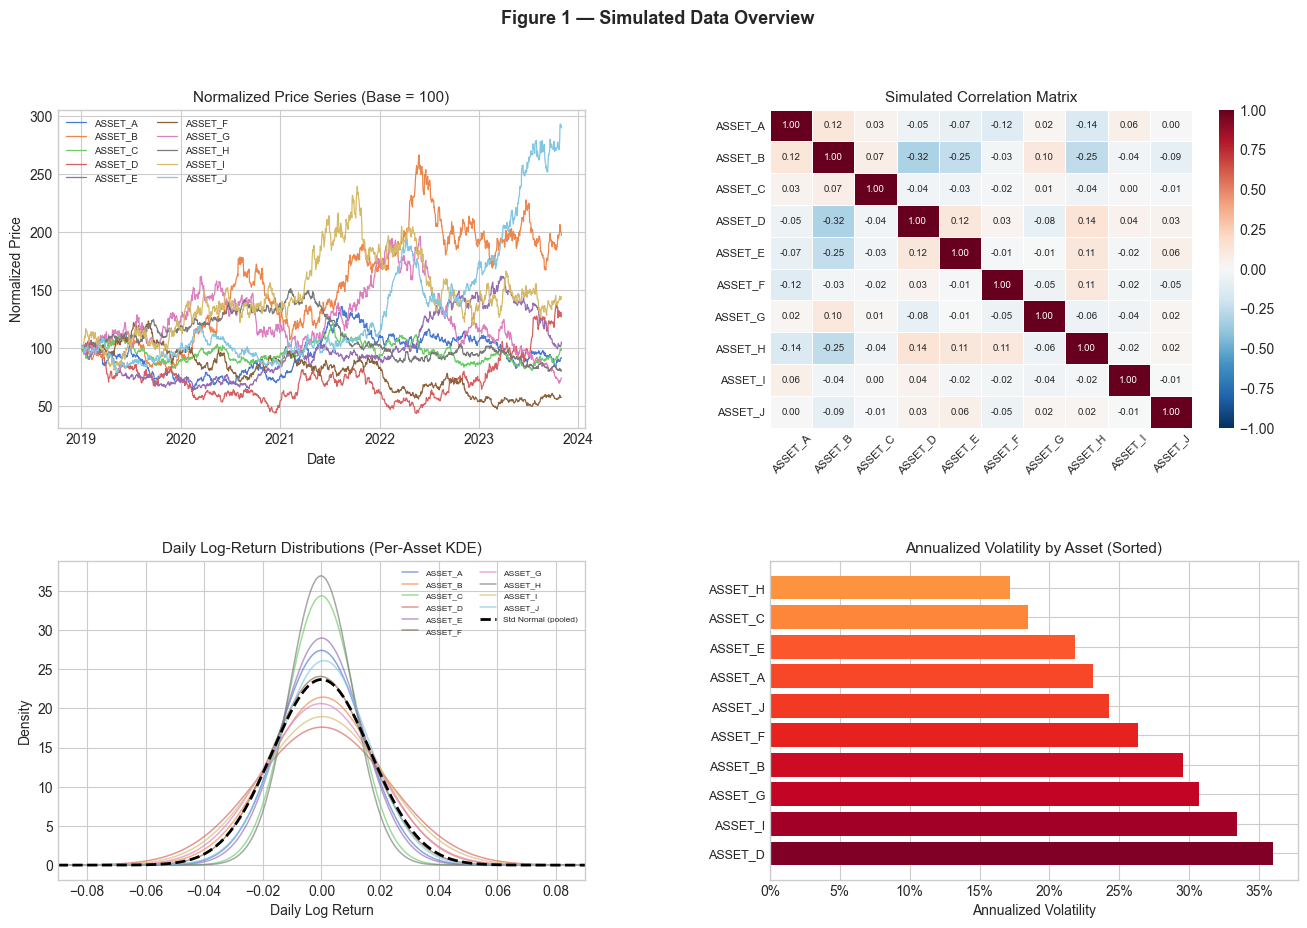

In [2]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Panel 1 — Normalized price series
normalized = prices.div(prices.iloc[0]) * 100
for i, col in enumerate(TICKERS):
    ax1.plot(normalized.index, normalized[col],
             label=col, color=PALETTE[i % len(PALETTE)], linewidth=0.9)
ax1.set_title("Normalized Price Series (Base = 100)", fontsize=11)
ax1.set_xlabel("Date")
ax1.set_ylabel("Normalized Price")
ax1.legend(loc="upper left", fontsize=7, ncol=2)

# Panel 2 — Correlation heatmap
corr_df = pd.DataFrame(corr_matrix, index=TICKERS, columns=TICKERS)
sns.heatmap(
    corr_df, ax=ax2, vmin=-1, vmax=1, cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.4,
)
ax2.set_title("Simulated Correlation Matrix", fontsize=11)
ax2.tick_params(axis="x", rotation=45, labelsize=8)
ax2.tick_params(axis="y", rotation=0,  labelsize=8)

# Panel 3 — Return KDE vs standard normal
x_grid = np.linspace(-0.09, 0.09, 300)
for i, col in enumerate(TICKERS):
    mu_r  = returns[col].mean()
    sig_r = returns[col].std()
    ax3.plot(x_grid, scipy_norm.pdf(x_grid, mu_r, sig_r),
             alpha=0.65, color=PALETTE[i % len(PALETTE)], linewidth=1.1, label=col)
pooled_std = returns.values.std()
ax3.plot(x_grid, scipy_norm.pdf(x_grid, 0, pooled_std),
         "k--", linewidth=2.0, label="Std Normal (pooled)")
ax3.set_title("Daily Log-Return Distributions (Per-Asset KDE)", fontsize=11)
ax3.set_xlabel("Daily Log Return")
ax3.set_ylabel("Density")
ax3.legend(fontsize=6, ncol=2)
ax3.set_xlim(-0.09, 0.09)

# Panel 4 — Annualized volatility bar chart (sorted)
ann_vols   = returns.std() * np.sqrt(252)
sorted_vols = ann_vols.sort_values(ascending=False)
cmap_vol   = plt.cm.YlOrRd
bar_colors = [cmap_vol(v / sorted_vols.max()) for v in sorted_vols.values]
ax4.barh(range(N_ASSETS), sorted_vols.values, color=bar_colors)
ax4.set_yticks(range(N_ASSETS))
ax4.set_yticklabels(sorted_vols.index, fontsize=9)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax4.set_title("Annualized Volatility by Asset (Sorted)", fontsize=11)
ax4.set_xlabel("Annualized Volatility")

fig.suptitle("Figure 1 — Simulated Data Overview", fontsize=13, fontweight="bold")
fig.savefig("../docs/figures/figure_01_price_series.png", dpi=150, bbox_inches="tight")
plt.show()

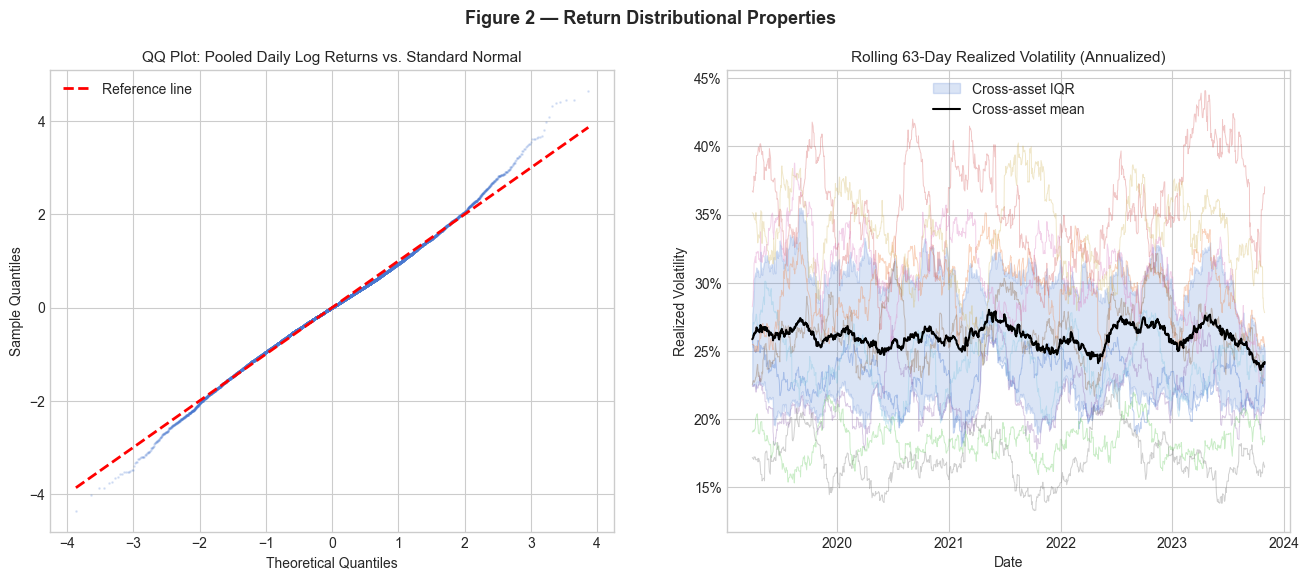

In [3]:
# Figure 2 — QQ plot and rolling volatility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 — QQ plot of pooled daily returns
pooled   = returns.values.flatten()
pooled_z = (pooled - pooled.mean()) / pooled.std()
(osm, osr), (slope, intercept, _) = probplot(pooled_z, dist="norm", fit=True)
ax1.scatter(osm, osr, alpha=0.15, s=1, color=PALETTE[0], rasterized=True)
x_line = np.array([osm.min(), osm.max()])
ax1.plot(x_line, slope * x_line + intercept, "r--", linewidth=2, label="Reference line")
ax1.set_title("QQ Plot: Pooled Daily Log Returns vs. Standard Normal", fontsize=11)
ax1.set_xlabel("Theoretical Quantiles")
ax1.set_ylabel("Sample Quantiles")
ax1.legend()

# Panel 2 — Rolling 63-day realized volatility
roll_vol  = returns.rolling(63).std() * np.sqrt(252)
mean_rv   = roll_vol.mean(axis=1)
q25_rv    = roll_vol.quantile(0.25, axis=1)
q75_rv    = roll_vol.quantile(0.75, axis=1)
for i, col in enumerate(TICKERS):
    ax2.plot(roll_vol.index, roll_vol[col],
             alpha=0.35, color=PALETTE[i % len(PALETTE)], linewidth=0.7)
ax2.fill_between(roll_vol.index, q25_rv, q75_rv,
                  alpha=0.20, color=PALETTE[0], label="Cross-asset IQR")
ax2.plot(roll_vol.index, mean_rv, color="black", linewidth=1.5, label="Cross-asset mean")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_title("Rolling 63-Day Realized Volatility (Annualized)", fontsize=11)
ax2.set_xlabel("Date")
ax2.set_ylabel("Realized Volatility")
ax2.legend()

fig.suptitle("Figure 2 — Return Distributional Properties", fontsize=13, fontweight="bold")
fig.savefig("../docs/figures/figure_02_return_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 2 — Expected Return Estimators

Three distinct estimators are compared, each with different underlying assumptions
about the data-generating process and the degree of prior information available.

### 2.1 Historical Mean Return

**Simple mean:**
$$\hat{\mu}_i = \frac{1}{T}\sum_{t=1}^{T} r_{i,t}, \quad
  \hat{\mu}_i^{\text{ann}} = (1 + \hat{\mu}_i)^{252} - 1$$

**Exponentially weighted mean** (span $s$, decay $\lambda = 1 - 2/(s+1)$):
$$\hat{\mu}_i^{\text{EWM}} = \sum_{t=1}^{T} w_t r_{i,t}, \quad
  w_t \propto \lambda^{T-t}, \quad \sum w_t = 1$$

The simple mean is an unbiased estimator but has high sampling variance
proportional to $\sigma_i / \sqrt{T}$. The EWM variant reduces effective sample
size in exchange for lower estimation lag under non-stationary drift.

### 2.2 CAPM-Implied Returns

$$\mathbb{E}[R_i] = R_f + \beta_i \bigl(\mathbb{E}[R_m] - R_f\bigr), \quad
  \beta_i = \frac{\text{Cov}(R_i^{\text{exc}}, R_m^{\text{exc}})}{\text{Var}(R_m^{\text{exc}})}$$

The CAPM estimator imposes the single-factor pricing restriction.
It is more robust than the historical mean when idiosyncratic noise dominates
the sample, but it is inconsistent if multi-factor pricing applies.

### 2.3 Black-Litterman Posterior

The Black-Litterman model combines a prior derived from equilibrium market
weights with investor views:

**Prior (implied equilibrium returns):**
$$\boldsymbol{\Pi} = \delta \boldsymbol{\Sigma} \mathbf{w}_{\text{mkt}}$$

**Posterior (Master Formula):**
$$\mathbf{M}^{-1} = (\tau\boldsymbol{\Sigma})^{-1} + \mathbf{P}^\top \boldsymbol{\Omega}^{-1}\mathbf{P}$$
$$\boldsymbol{\mu}_{\text{BL}} = \mathbf{M}\!\left[
  (\tau\boldsymbol{\Sigma})^{-1}\boldsymbol{\Pi}
  + \mathbf{P}^\top \boldsymbol{\Omega}^{-1}\mathbf{Q}
\right]$$

**Idzorek view uncertainty:**
$\boldsymbol{\Omega} = \text{diag}\bigl(\tau\, \mathbf{P}\boldsymbol{\Sigma}\mathbf{P}^\top\bigr)$

Two views are encoded below: (1) ASSET_D outperforms ASSET_C by 5%
(relative view), and (2) ASSET_B has an expected return of 13% (absolute view).

In [4]:
from quantopt.returns.estimators import (
    MeanHistoricalReturn, CAPMReturn, BlackLittermanReturn,
)
from quantopt.risk.covariance import LedoitWolfCovariance

# ── Historical mean (simple and EWM) ─────────────────────────────────────────
mhr_simple = MeanHistoricalReturn(exponential_weighting=False).fit(returns)
mu_simple  = mhr_simple.expected_returns()

mhr_ewm = MeanHistoricalReturn(exponential_weighting=True, span=60).fit(returns)
mu_ewm  = mhr_ewm.expected_returns()

# ── CAPM (equal-weight portfolio as market) ───────────────────────────────────
market_returns = returns.mean(axis=1)
capm = CAPMReturn(market_returns=market_returns, risk_free_rate=0.02).fit(returns)
mu_capm = capm.expected_returns()

print(f"CAPM betas:\n{capm.betas_.round(3)}")
print(f"Market equity premium: {capm.market_premium_:.2%}")

# ── Black-Litterman ───────────────────────────────────────────────────────────
# Use Ledoit-Wolf covariance as the prior covariance input
lw_est    = LedoitWolfCovariance().fit(returns)
Sigma_lw  = lw_est.covariance()

market_caps = pd.Series(np.ones(N_ASSETS) / N_ASSETS, index=TICKERS)

# View 1: ASSET_D outperforms ASSET_C by 5% (relative)
# View 2: ASSET_B expected return = 13% (absolute)
P = np.zeros((2, N_ASSETS))
P[0, TICKERS.index("ASSET_D")] =  1.0
P[0, TICKERS.index("ASSET_C")] = -1.0
P[1, TICKERS.index("ASSET_B")] =  1.0
Q = np.array([0.05, 0.13])

bl = BlackLittermanReturn(
    market_caps=market_caps, risk_aversion=2.5, tau=0.05, P=P, Q=Q,
).fit(returns)
mu_bl  = bl.expected_returns()
pi_bl  = bl.pi_

print("\nEstimator summary (annualized returns):")
comparison = pd.DataFrame({
    "True mu"        : pd.Series(mu_annual, index=TICKERS),
    "Hist (Simple)"  : mu_simple,
    "Hist (EWM-60)"  : mu_ewm,
    "CAPM"           : mu_capm,
    "BL Prior (Pi)"  : pi_bl,
    "BL Posterior"   : mu_bl,
})
print(comparison.applymap(lambda v: f"{v:.2%}"))

CAPM betas:
ASSET_A    0.723
ASSET_B    0.568
ASSET_C    0.580
ASSET_D    1.813
ASSET_E    0.816
ASSET_F    0.994
ASSET_G    1.423
ASSET_H    0.385
ASSET_I    1.720
ASSET_J    0.979
dtype: float64
Market equity premium: 0.62%



Estimator summary (annualized returns):
        True mu Hist (Simple) Hist (EWM-60)   CAPM BL Prior (Pi) BL Posterior
ASSET_A  10.00%        -0.98%        11.71%  2.45%         1.04%        1.72%
ASSET_B  12.00%        14.47%        28.32%  2.35%         0.82%        6.59%
ASSET_C   8.00%        -0.04%       115.89%  2.36%         0.83%        0.45%
ASSET_D  15.00%         4.57%        22.84%  3.12%         2.61%        2.49%
ASSET_E   9.00%         1.21%       -34.43%  2.50%         1.17%       -0.07%
ASSET_F  11.00%       -10.14%         8.30%  2.61%         1.43%        1.21%
ASSET_G  13.00%        -5.72%       -45.29%  2.88%         2.04%        2.67%
ASSET_H   7.00%        -4.20%       -17.98%  2.24%         0.55%       -0.22%
ASSET_I  14.00%         7.34%        32.17%  3.06%         2.47%        2.19%
ASSET_J  10.00%        23.92%        77.29%  2.60%         1.41%        0.99%


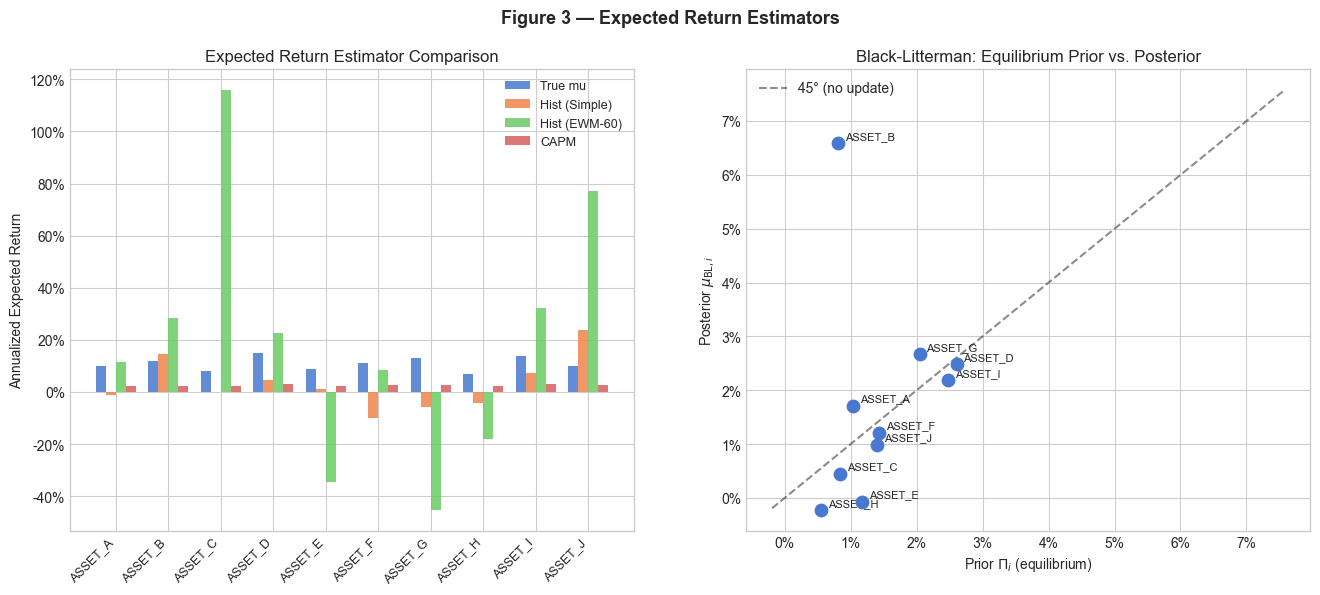

In [5]:
# Figure 3 — Return estimator comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1 — Grouped bar chart
x     = np.arange(N_ASSETS)
width = 0.19
datasets = [
    ("True mu",         mu_annual,       PALETTE[0]),
    ("Hist (Simple)",   mu_simple.values, PALETTE[1]),
    ("Hist (EWM-60)",   mu_ewm.values,   PALETTE[2]),
    ("CAPM",            mu_capm.values,  PALETTE[3]),
]
for i, (label, dat, col) in enumerate(datasets):
    ax1.bar(x + i * width, dat, width, label=label, color=col, alpha=0.85)
ax1.set_xticks(x + 1.5 * width)
ax1.set_xticklabels(TICKERS, rotation=45, ha="right", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax1.set_title("Expected Return Estimator Comparison", fontsize=12)
ax1.set_ylabel("Annualized Expected Return")
ax1.legend(fontsize=9)

# Panel 2 — BL: prior (Pi) vs posterior (mu_BL)
ax2.scatter(pi_bl.values, mu_bl.values, color=PALETTE[0], s=80, zorder=5)
for i, tkr in enumerate(TICKERS):
    ax2.annotate(
        tkr, (pi_bl[tkr], mu_bl[tkr]),
        textcoords="offset points", xytext=(5, 3), fontsize=8,
    )
lim_lo = min(pi_bl.min(), mu_bl.min()) * 0.85
lim_hi = max(pi_bl.max(), mu_bl.max()) * 1.15
ax2.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", alpha=0.45, label="45° (no update)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_title("Black-Litterman: Equilibrium Prior vs. Posterior", fontsize=12)
ax2.set_xlabel("Prior $\\Pi_i$ (equilibrium)")
ax2.set_ylabel("Posterior $\\mu_{\\mathrm{BL},i}$")
ax2.legend()

fig.suptitle("Figure 3 — Expected Return Estimators", fontsize=13, fontweight="bold")
fig.savefig("../docs/figures/figure_03_return_estimators.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 3 — Covariance Estimation

In high-dimensional settings, the sample covariance matrix $\mathbf{S}$ accumulates
estimation error at a rate proportional to $N^2/T$. When $N/T$ is non-negligible,
the smallest eigenvalues of $\mathbf{S}$ are systematically underestimated and the
matrix becomes ill-conditioned.

In this simulation, $T/N = 126$, which is comfortably large. On real portfolios
with $N = 100$ assets and $T = 252$ observations, $T/N = 2.52$ and the sample
covariance is nearly singular; shrinkage and factor models are indispensable.

### Ledoit-Wolf Oracle Approximating Shrinkage (OAS)

The OAS estimator linearly blends the sample covariance $\mathbf{S}$ toward a
multiple of the identity:

$$\hat{\boldsymbol{\Sigma}}^{\text{LW}} = (1 - \alpha)\mathbf{S} + \alpha\,\bar{\mu}\mathbf{I}$$

where $\bar{\mu} = \text{tr}(\mathbf{S})/N$ and
$\alpha^* = \arg\min_{\alpha}\;\mathbb{E}\!\left[\|\hat{\boldsymbol{\Sigma}} - \boldsymbol{\Sigma}_{\text{true}}\|_F^2\right]$
is estimated analytically from the data via the OAS formula of Chen et al. (2010).

### Barra-Style Factor Model (PCA)

The $K$-factor model decomposes the covariance matrix as:

$$\boldsymbol{\Sigma} = \mathbf{B}\mathbf{F}\mathbf{B}^\top + \mathbf{D}$$

where $\mathbf{B}$ ($N \times K$) contains the factor loadings extracted by PCA,
$\mathbf{F}$ ($K \times K$) is the factor covariance matrix (diagonal for
orthogonal PCA factors), and $\mathbf{D} = \text{diag}(d_1,\ldots,d_N)$
is the diagonal idiosyncratic variance. Setting $K = 3$ in this notebook
captures the three latent factors used to generate the simulated correlation.

In [6]:
from quantopt.risk.covariance import (
    SampleCovariance, EWMCovariance,
    LedoitWolfCovariance, FactorModelCovariance,
)

cov_sample = SampleCovariance().fit(returns)
cov_ewm    = EWMCovariance(span=60).fit(returns)
cov_lw     = LedoitWolfCovariance().fit(returns)
cov_fm     = FactorModelCovariance(n_factors=3).fit(returns)

Sigma_sample = cov_sample.covariance()
Sigma_ewm    = cov_ewm.covariance()
Sigma_lw     = cov_lw.covariance()
Sigma_fm     = cov_fm.covariance()

print(f"LW shrinkage alpha          : {cov_lw.shrinkage_:.4f}")
print(f"LW sample weight            : {1 - cov_lw.shrinkage_:.4f}")
print(f"Factor model factors used   : {cov_fm.n_factors_used_}")
print(f"Explained variance ratios   : {np.round(cov_fm.explained_variance_ratio_, 3)}")
print(f"Sample cov condition number : {cov_sample.condition_number_:.1f}")

LW shrinkage alpha          : 0.0295
LW sample weight            : 0.9705
Factor model factors used   : 3
Explained variance ratios   : [0.225 0.159 0.125]
Sample cov condition number : 6.2


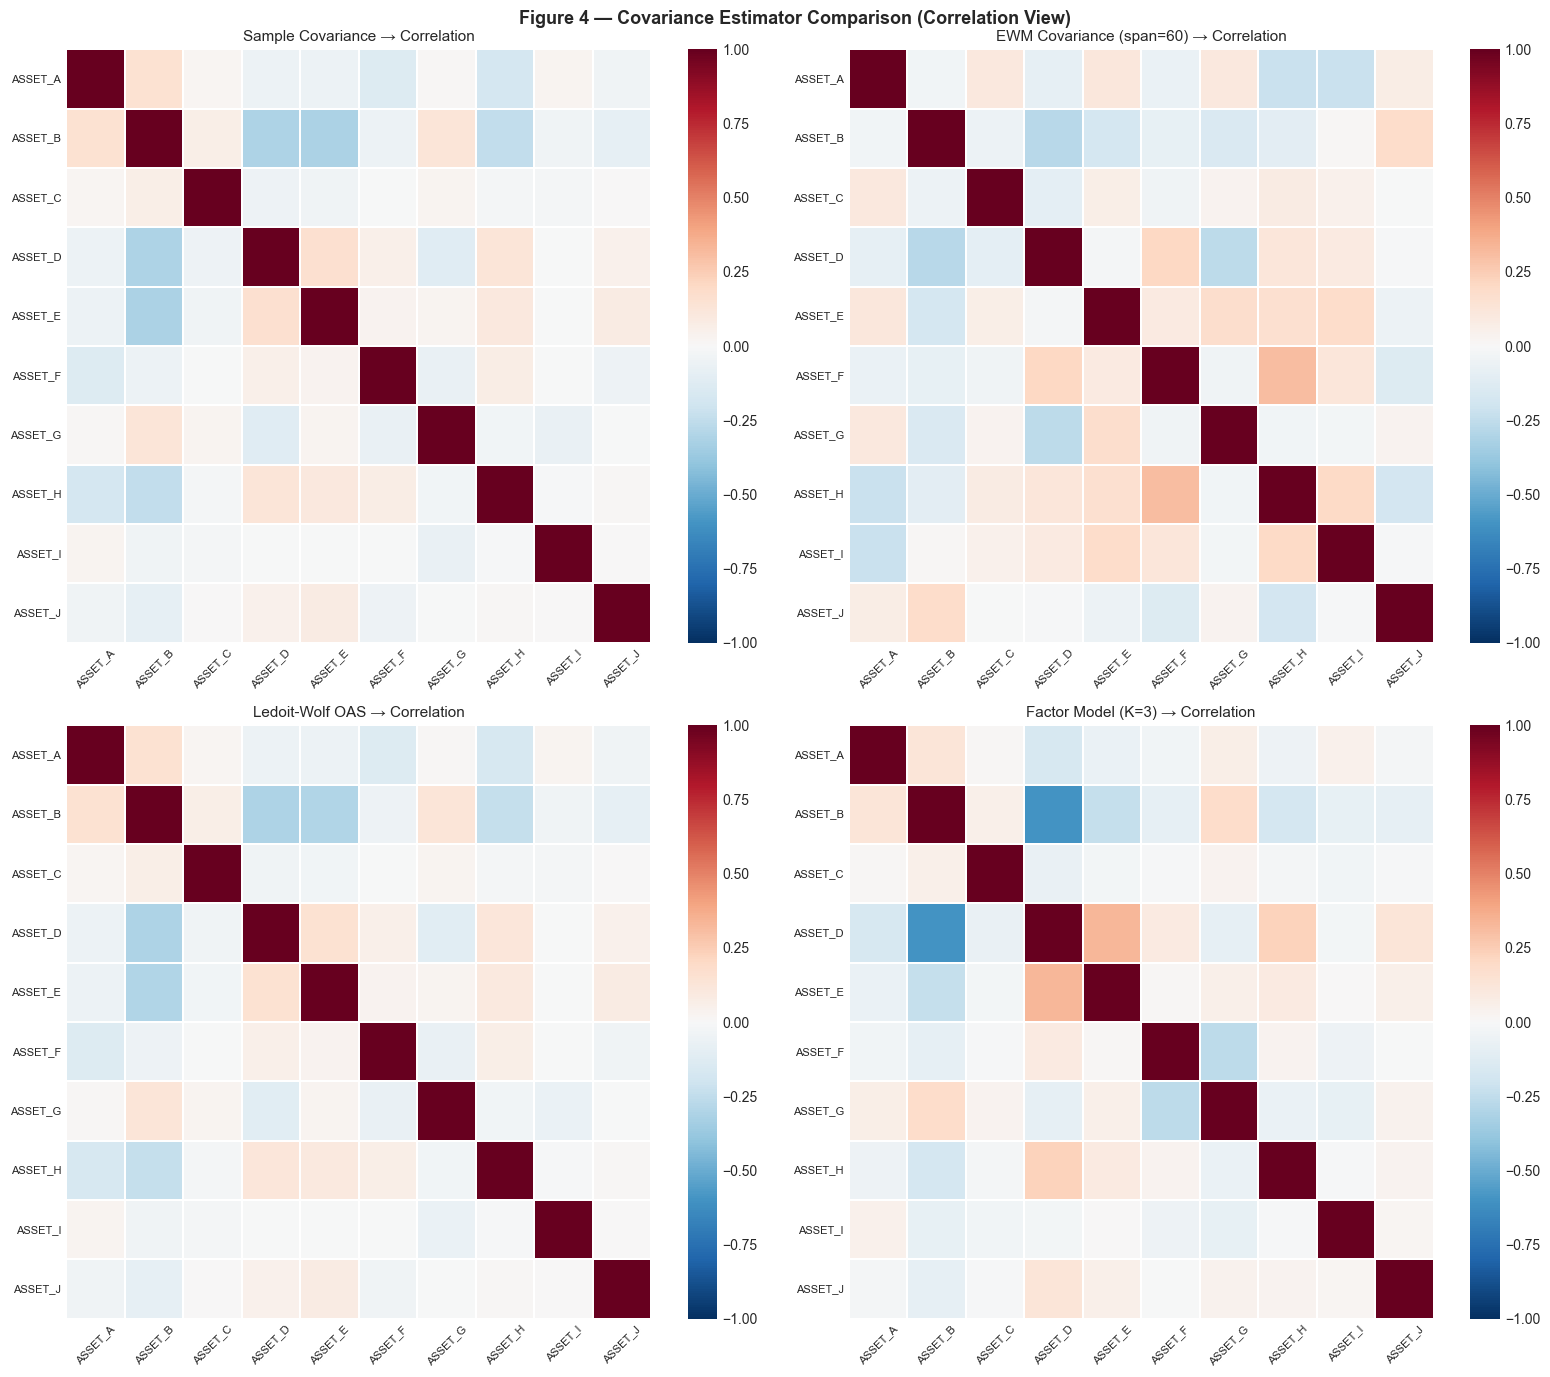

In [7]:
# Figure 4 — Covariance estimator correlation matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

estimators_data = [
    (cov_sample.correlation(), "Sample Covariance → Correlation"),
    (cov_ewm.correlation(),    "EWM Covariance (span=60) → Correlation"),
    (cov_lw.correlation(),     "Ledoit-Wolf OAS → Correlation"),
    (cov_fm.correlation(),     "Factor Model (K=3) → Correlation"),
]

for ax, (corr, title) in zip(axes.flat, estimators_data):
    sns.heatmap(
        corr, ax=ax, vmin=-1, vmax=1, cmap="RdBu_r", center=0,
        annot=False, linewidths=0.3,
        xticklabels=TICKERS, yticklabels=TICKERS,
    )
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

fig.suptitle(
    "Figure 4 — Covariance Estimator Comparison (Correlation View)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
fig.savefig("../docs/figures/figure_04_covariance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

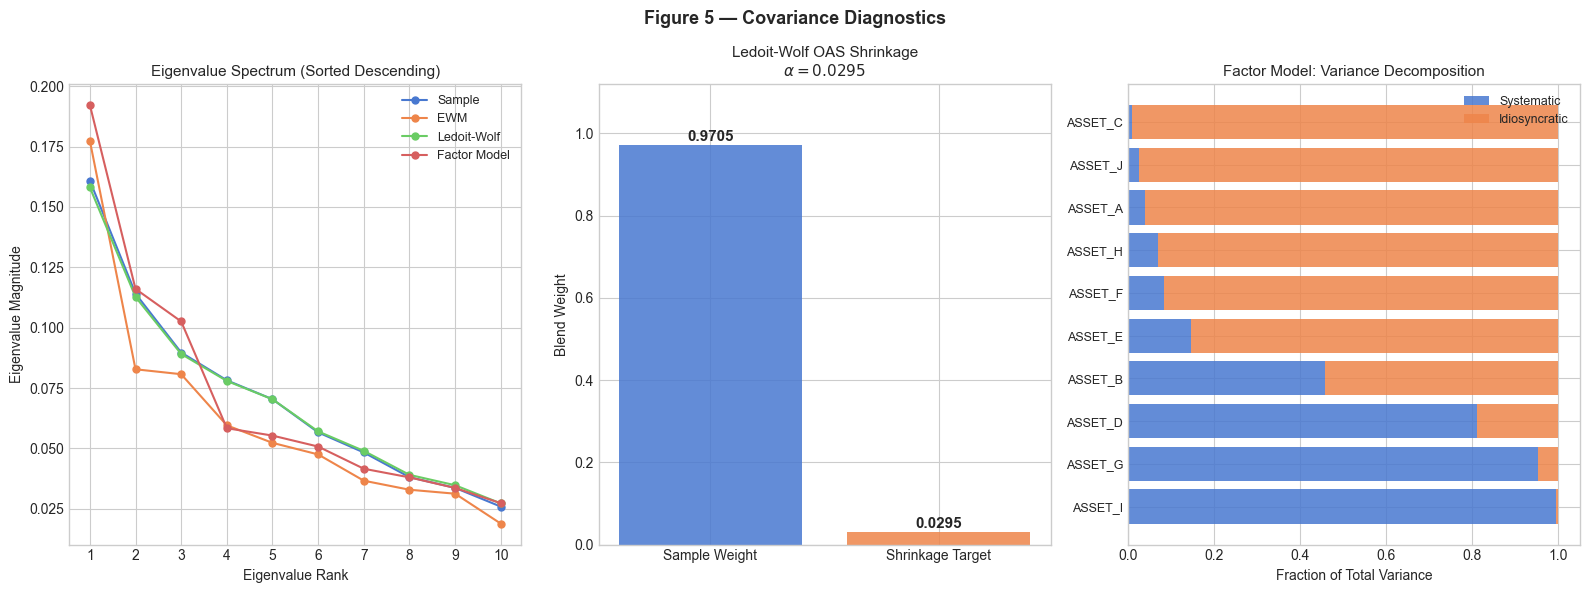

In [8]:
# Figure 5 — Covariance diagnostics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

# Panel 1 — Eigenvalue spectra
cov_list   = [Sigma_sample, Sigma_ewm, Sigma_lw, Sigma_fm]
cov_labels = ["Sample", "EWM", "Ledoit-Wolf", "Factor Model"]
for i, (S, lbl) in enumerate(zip(cov_list, cov_labels)):
    eigvals = np.sort(np.linalg.eigvalsh(S.values))[::-1]
    ax1.plot(range(1, len(eigvals) + 1), eigvals,
             "o-", label=lbl, color=PALETTE[i], markersize=5)
ax1.set_title("Eigenvalue Spectrum (Sorted Descending)", fontsize=11)
ax1.set_xlabel("Eigenvalue Rank")
ax1.set_ylabel("Eigenvalue Magnitude")
ax1.set_xticks(range(1, N_ASSETS + 1))
ax1.legend(fontsize=9)

# Panel 2 — Shrinkage intensity
alpha_lw    = cov_lw.shrinkage_
sample_wt   = 1.0 - alpha_lw
ax2.bar(["Sample Weight", "Shrinkage Target"], [sample_wt, alpha_lw],
        color=[PALETTE[0], PALETTE[1]], alpha=0.85)
for i, v in enumerate([sample_wt, alpha_lw]):
    ax2.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 1.12)
ax2.set_title(f"Ledoit-Wolf OAS Shrinkage\n$\\alpha = {alpha_lw:.4f}$", fontsize=11)
ax2.set_ylabel("Blend Weight")

# Panel 3 — Factor model: systematic vs idiosyncratic variance
B         = cov_fm.factor_loadings_.values
F_cov     = cov_fm.factor_covariance_.values
D_idio    = cov_fm.idiosyncratic_var_.values
sys_var   = np.diag(B @ F_cov @ B.T)
total_var = sys_var + D_idio
frac_sys  = sys_var / total_var
sort_idx  = np.argsort(frac_sys)[::-1]
sorted_tickers = [TICKERS[i] for i in sort_idx]
ax3.barh(range(N_ASSETS), [frac_sys[i] for i in sort_idx],
         label="Systematic", color=PALETTE[0], alpha=0.85)
ax3.barh(range(N_ASSETS), [1 - frac_sys[i] for i in sort_idx],
         left=[frac_sys[i] for i in sort_idx],
         label="Idiosyncratic", color=PALETTE[1], alpha=0.85)
ax3.set_yticks(range(N_ASSETS))
ax3.set_yticklabels(sorted_tickers, fontsize=9)
ax3.set_title("Factor Model: Variance Decomposition", fontsize=11)
ax3.set_xlabel("Fraction of Total Variance")
ax3.legend(fontsize=9)

fig.suptitle("Figure 5 — Covariance Diagnostics", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_05_covariance_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 4 — Portfolio Optimization: Mean-Variance Efficient Frontier

The Markowitz (1952) mean-variance framework poses three canonical problems.
All are solved via SLSQP (Sequential Least Squares Programming) with five
independent Dirichlet random restarts to mitigate local-optima risk.

**Problem P1 — Maximum Sharpe Ratio (Tangency Portfolio):**
$$\max_{\mathbf{w}}\;
\frac{\mathbf{w}^\top\boldsymbol{\mu} - R_f}{\sqrt{\mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w}}}
\quad\text{s.t.}\quad \mathbf{1}^\top\mathbf{w} = 1,\; \mathbf{w} \ge \mathbf{0}$$

**Problem P2 — Minimum Variance:**
$$\min_{\mathbf{w}}\; \mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w}
\quad\text{s.t.}\quad \mathbf{1}^\top\mathbf{w} = 1,\; \mathbf{w} \ge \mathbf{0}$$

**Problem P3 — Efficient Return (target $\mu^*$):**
$$\min_{\mathbf{w}}\; \mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w}
\quad\text{s.t.}\quad \mathbf{1}^\top\mathbf{w} = 1,\;
\mathbf{w}^\top\boldsymbol{\mu} \ge \mu^*,\; \mathbf{w} \ge \mathbf{0}$$

**L2 regularization** penalizes weight concentration, effectively smoothing
the objective toward the equal-weight portfolio as $\gamma \to \infty$:
$$\text{Objective}_{\text{reg}} = f(\mathbf{w}) + \gamma\,\mathbf{w}^\top\mathbf{w}$$

The analytical gradient used in P1 (SLSQP) is:
$$\nabla_{\mathbf{w}}(-\text{SR}) = -\frac{
  \boldsymbol{\mu}\,\sigma_p - (\mathbf{w}^\top\boldsymbol{\mu} - R_f)
  \,\boldsymbol{\Sigma}\mathbf{w} / \sigma_p
}{\sigma_p^2} + 2\gamma\mathbf{w}$$
where $\sigma_p = \sqrt{\mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w}}$.

In [9]:
from quantopt.optimization.efficient_frontier import EfficientFrontier, InfeasibleError

# ── Fit three canonical portfolios ───────────────────────────────────────────
ef_ms = EfficientFrontier(mu=mu_bl, Sigma=Sigma_lw)
w_max_sharpe = ef_ms.max_sharpe(risk_free_rate=0.02)
ret_ms, vol_ms, sr_ms = ef_ms.portfolio_performance(
    mu=mu_bl, Sigma=Sigma_lw, risk_free_rate=0.02
)

ef_mv = EfficientFrontier(mu=mu_bl, Sigma=Sigma_lw)
w_min_vol = ef_mv.min_volatility()
ret_mv, vol_mv, sr_mv = ef_mv.portfolio_performance(
    mu=mu_bl, Sigma=Sigma_lw, risk_free_rate=0.02
)

eff_ret_target = float(mu_bl.max() * 0.80)  # 80% of max BL return — always feasible
ef_er = EfficientFrontier(mu=mu_bl, Sigma=Sigma_lw)
w_eff_ret = ef_er.efficient_return(target_return=eff_ret_target)
ret_er, vol_er, sr_er = ef_er.portfolio_performance(
    mu=mu_bl, Sigma=Sigma_lw, risk_free_rate=0.02
)

print(f"Max Sharpe  : ret={ret_ms:.2%}  vol={vol_ms:.2%}  SR={sr_ms:.3f}")
print(f"Min Vol     : ret={ret_mv:.2%}  vol={vol_mv:.2%}  SR={sr_mv:.3f}")
print(f"Eff Return  : ret={ret_er:.2%}  vol={vol_er:.2%}  SR={sr_er:.3f}  (target={eff_ret_target:.2%})")

# ── Trace the full efficient frontier ────────────────────────────────────────
ef_front = EfficientFrontier(mu=mu_bl, Sigma=Sigma_lw)
frontier_df = ef_front.efficient_frontier_points(n_points=60, risk_free_rate=0.02)
print(f"\nFrontier points computed: {len(frontier_df)}")

Max Sharpe  : ret=5.34%  vol=19.75%  SR=0.169
Min Vol     : ret=1.52%  vol=6.91%  SR=-0.069
Eff Return  : ret=5.27%  vol=19.34%  SR=0.169  (target=5.27%)

Frontier points computed: 60


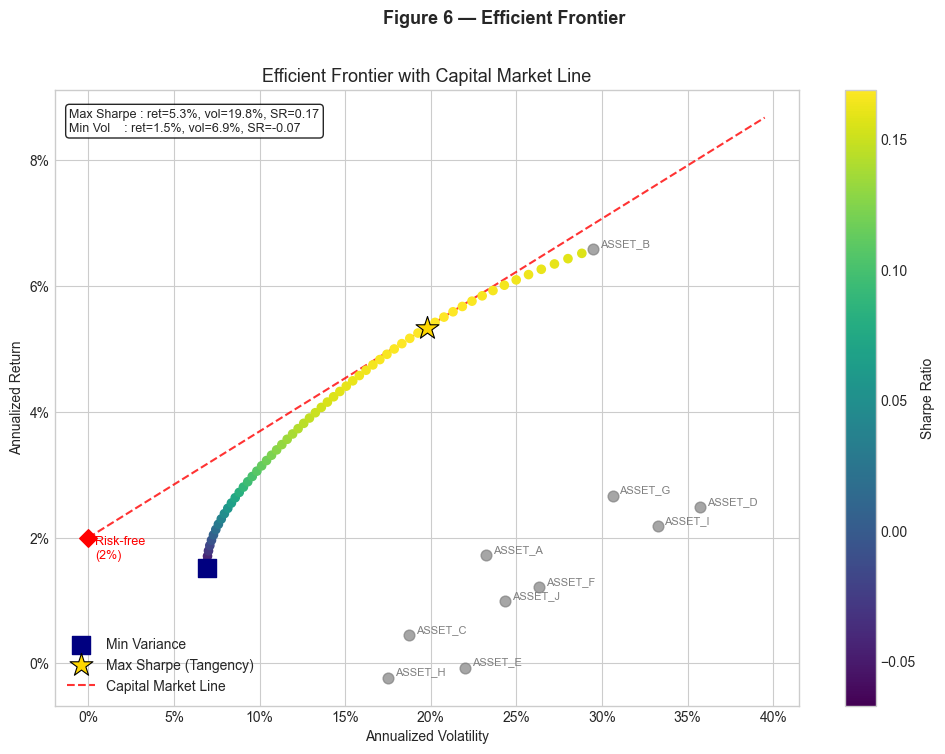

In [10]:
# Figure 6 — Efficient frontier
RF = 0.02

fig, ax = plt.subplots(figsize=(12, 8))

# Frontier colored by Sharpe ratio
sc = ax.scatter(
    frontier_df["volatility"] * 100,
    frontier_df["return"] * 100,
    c=frontier_df["sharpe"],
    cmap="viridis", s=35, zorder=4,
)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")

# Individual assets
asset_vols = np.sqrt(np.diag(Sigma_lw.values)) * 100
asset_rets = mu_bl.values * 100
ax.scatter(asset_vols, asset_rets, c="grey", s=60, alpha=0.7, zorder=3)
for i, tkr in enumerate(TICKERS):
    ax.annotate(tkr, (asset_vols[i], asset_rets[i]),
                textcoords="offset points", xytext=(5, 2), fontsize=8, color="grey")

# Min variance portfolio
ax.scatter(vol_mv * 100, ret_mv * 100,
           marker="s", s=150, color="navy", zorder=6, label="Min Variance")

# Max Sharpe (tangency) portfolio
ax.scatter(vol_ms * 100, ret_ms * 100,
           marker="*", s=300, color="gold", edgecolors="black",
           linewidths=0.8, zorder=7, label="Max Sharpe (Tangency)")

# Capital Market Line
cml_vol_max = vol_ms * 2.0
cml_vols    = np.linspace(0, cml_vol_max * 100, 200)
cml_rets    = RF * 100 + (ret_ms - RF) / vol_ms * (cml_vols / 100) * 100
ax.plot(cml_vols, cml_rets, "r--", linewidth=1.5, alpha=0.8, label="Capital Market Line")
ax.scatter(0, RF * 100, marker="D", s=80, color="red", zorder=6)
ax.annotate(f"Risk-free\n({RF:.0%})", (0, RF * 100),
            textcoords="offset points", xytext=(5, -15), fontsize=9, color="red")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.set_title("Efficient Frontier with Capital Market Line", fontsize=13)
ax.legend(fontsize=10)

# Annotation box
textstr = (
    f"Max Sharpe : ret={ret_ms:.1%}, vol={vol_ms:.1%}, SR={sr_ms:.2f}\n"
    f"Min Vol    : ret={ret_mv:.1%}, vol={vol_mv:.1%}, SR={sr_mv:.2f}"
)
ax.text(0.02, 0.97, textstr, transform=ax.transAxes,
        fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

fig.suptitle("Figure 6 — Efficient Frontier", fontsize=13, fontweight="bold")
fig.savefig("../docs/figures/figure_06_efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

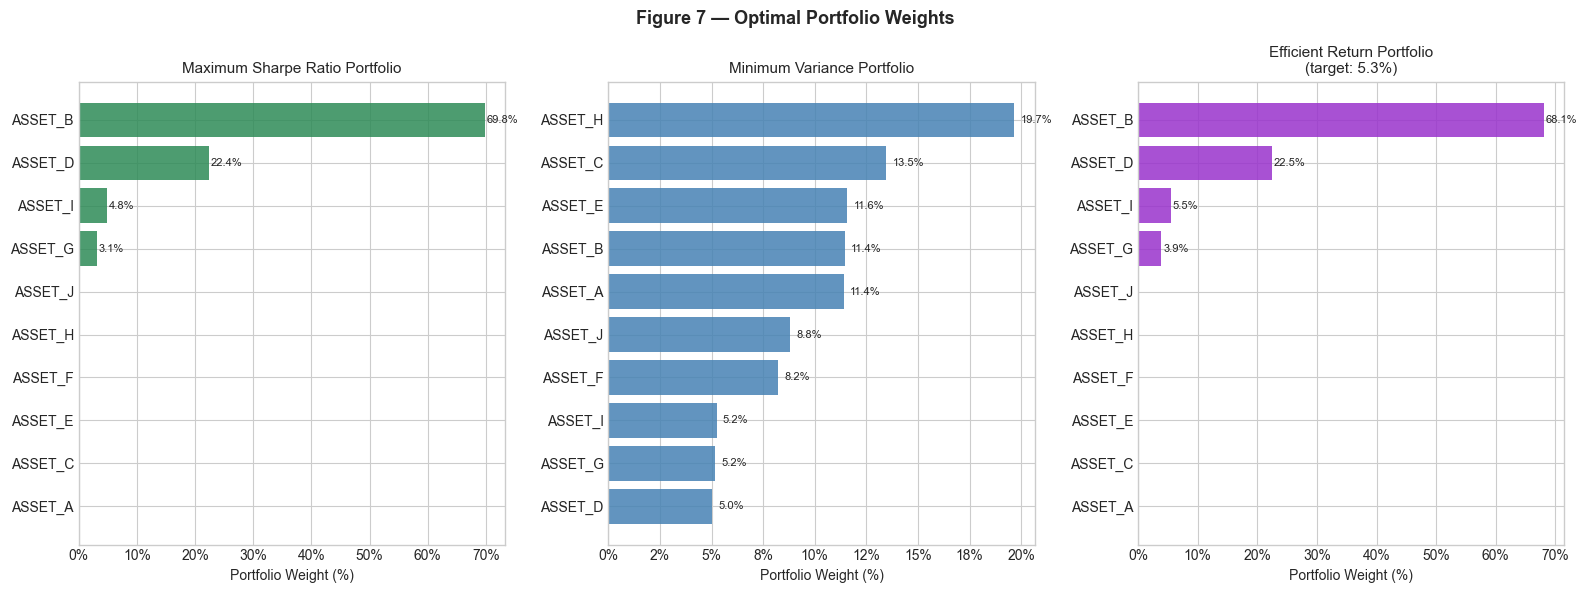

In [11]:
# Figure 7 — Optimal portfolio weights
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

portfolios = [
    (w_max_sharpe, "Maximum Sharpe Ratio Portfolio",     "seagreen"),
    (w_min_vol,    "Minimum Variance Portfolio",          "steelblue"),
    (w_eff_ret,    f"Efficient Return Portfolio\n(target: {eff_ret_target:.1%})", "darkorchid"),
]

for ax, (w, title, color) in zip(axes, portfolios):
    sorted_w = w.sort_values(ascending=True)
    ax.barh(sorted_w.index, sorted_w.values * 100, color=color, alpha=0.85)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.set_xlabel("Portfolio Weight (%)")
    ax.set_title(title, fontsize=11)
    for i, (idx, v) in enumerate(sorted_w.items()):
        if v > 0.005:
            ax.text(v * 100 + 0.3, i, f"{v:.1%}", va="center", fontsize=8)

fig.suptitle("Figure 7 — Optimal Portfolio Weights", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_07_optimal_weights.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 — Equal Risk Contribution (Risk Parity)

Risk parity departs from the Markowitz framework by treating risk allocation,
rather than capital allocation, as the design variable.

### Risk Contribution Framework (Roncalli, 2013)

Portfolio volatility decomposes by Euler's theorem as:
$$\sigma_p = \sum_{i=1}^{N} \underbrace{w_i \cdot \text{MRC}_i}_{\text{CRC}_i}, \quad
  \text{MRC}_i = \frac{(\boldsymbol{\Sigma}\mathbf{w})_i}{\sigma_p}$$

The percentage risk contribution is:
$$\text{PRC}_i = \frac{\text{CRC}_i}{\sigma_p}, \quad \sum_i \text{PRC}_i = 1$$

The **Equal Risk Contribution** (ERC) condition requires
$\text{CRC}_i = \text{CRC}_j$ for all $i, j$, or equivalently
$\text{PRC}_i = 1/N$. The generalized risk budgeting problem is:

$$\min_{\mathbf{w}}\; \sum_{i=1}^{N}\!
  \Bigl(\text{CRC}_i - b_i\, \sigma_p\Bigr)^2
\quad\text{s.t.}\quad \mathbf{1}^\top\mathbf{w} = 1,\; \mathbf{w} \ge \mathbf{0}$$

where $b_i$ is the target risk budget for asset $i$ (here $b_i = 1/N$).
The objective is solved with 15 Dirichlet random restarts via SLSQP.

In [12]:
from quantopt.optimization.risk_parity import RiskParity
from quantopt.risk.metrics import (
    percent_risk_contribution, diversification_ratio, concentration_hhi, effective_n,
)

rp = RiskParity(Sigma=Sigma_lw)
w_rp = rp.optimize()
prc_rp = rp.risk_contributions()

prc_ms = percent_risk_contribution(w_max_sharpe, Sigma_lw)
prc_mv = percent_risk_contribution(w_min_vol,    Sigma_lw)

dr_ms = diversification_ratio(w_max_sharpe, Sigma_lw)
dr_mv = diversification_ratio(w_min_vol,    Sigma_lw)
dr_rp = diversification_ratio(w_rp,         Sigma_lw)

hhi_ms = concentration_hhi(w_max_sharpe)
hhi_mv = concentration_hhi(w_min_vol)
hhi_rp = concentration_hhi(w_rp)

print("Risk contributions (ERC portfolio):")
print(prc_rp.round(4).to_string())
print(f"\nDiversification Ratios — MS: {dr_ms:.3f}  MV: {dr_mv:.3f}  RP: {dr_rp:.3f}")
print(f"HHI                   — MS: {hhi_ms:.4f}  MV: {hhi_mv:.4f}  RP: {hhi_rp:.4f}")
print(f"Effective N           — MS: {effective_n(w_max_sharpe):.2f}  "
      f"MV: {effective_n(w_min_vol):.2f}  RP: {effective_n(w_rp):.2f}")

Risk contributions (ERC portfolio):
ASSET_A    0.1
ASSET_B    0.1
ASSET_C    0.1
ASSET_D    0.1
ASSET_E    0.1
ASSET_F    0.1
ASSET_G    0.1
ASSET_H    0.1
ASSET_I    0.1
ASSET_J    0.1

Diversification Ratios — MS: 1.574  MV: 3.468  RP: 3.536
HHI                   — MS: 0.5405  MV: 0.1187  RP: 0.1049
Effective N           — MS: 1.85  MV: 8.42  RP: 9.53


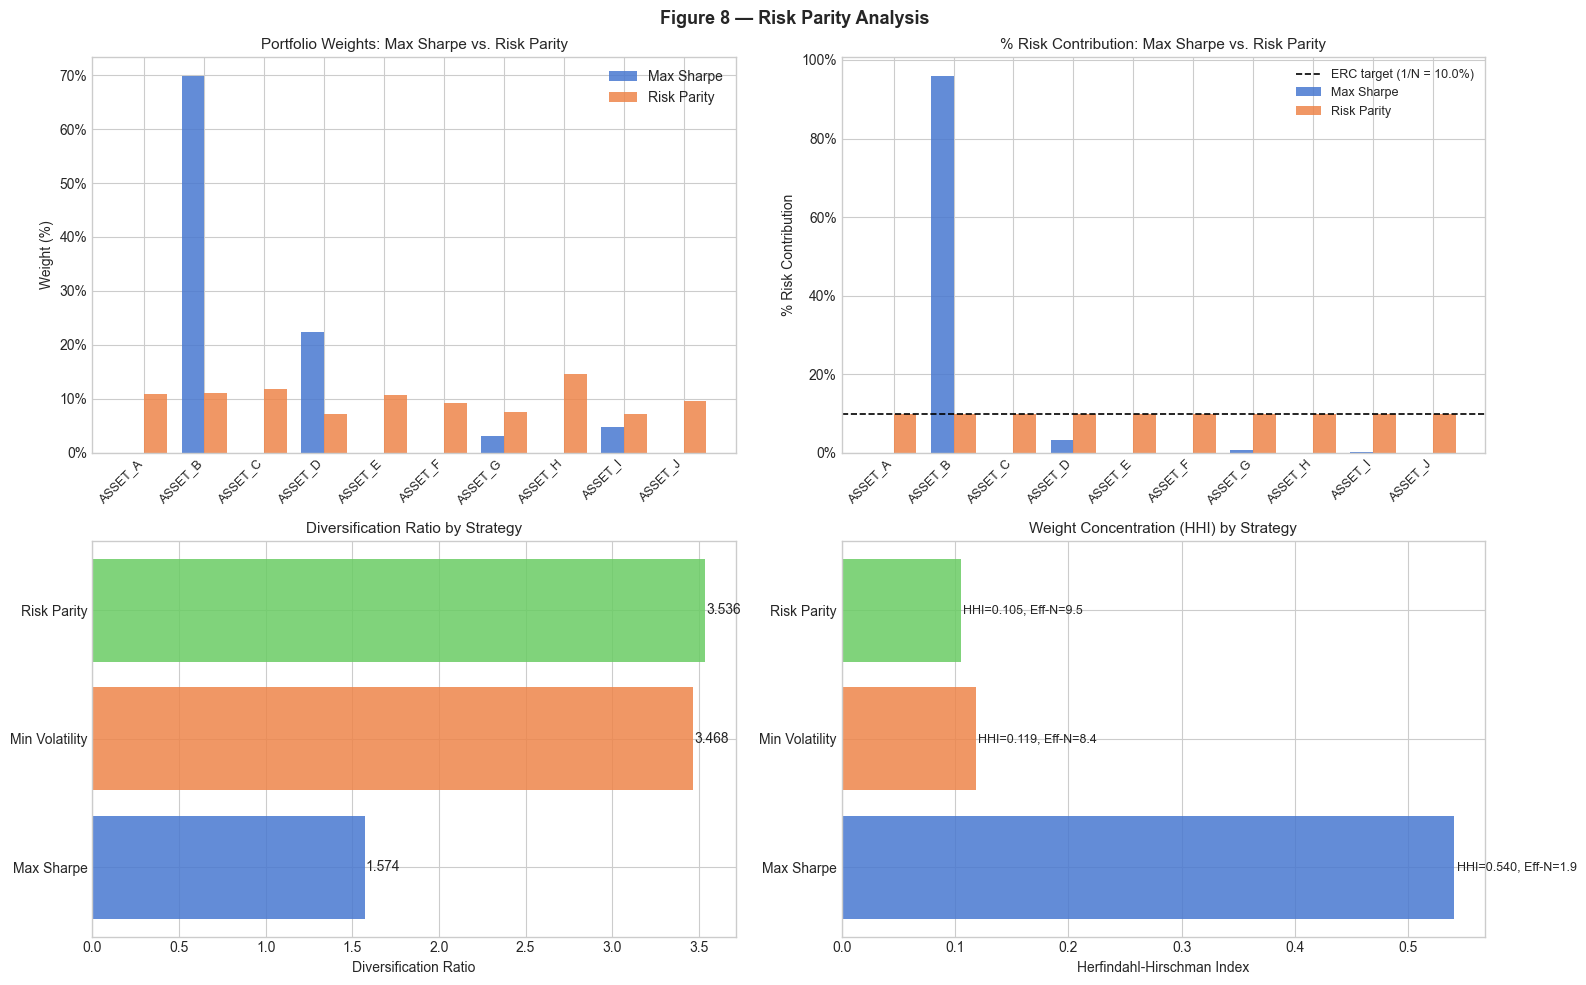

In [13]:
# Figure 8 — Risk parity analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax_tl, ax_tr, ax_bl, ax_br = axes.flat

x      = np.arange(N_ASSETS)
width2 = 0.38

# Top-left — Weight comparison
ax_tl.bar(x - width2 / 2, w_max_sharpe.values * 100, width2,
          label="Max Sharpe", color=PALETTE[0], alpha=0.85)
ax_tl.bar(x + width2 / 2, w_rp.values * 100,        width2,
          label="Risk Parity", color=PALETTE[1], alpha=0.85)
ax_tl.set_xticks(x)
ax_tl.set_xticklabels(TICKERS, rotation=45, ha="right", fontsize=9)
ax_tl.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_tl.set_title("Portfolio Weights: Max Sharpe vs. Risk Parity", fontsize=11)
ax_tl.set_ylabel("Weight (%)")
ax_tl.legend()

# Top-right — Risk contribution comparison
erc_target = 100.0 / N_ASSETS
ax_tr.bar(x - width2 / 2, prc_ms.values * 100, width2,
          label="Max Sharpe", color=PALETTE[0], alpha=0.85)
ax_tr.bar(x + width2 / 2, prc_rp.values * 100, width2,
          label="Risk Parity", color=PALETTE[1], alpha=0.85)
ax_tr.axhline(erc_target, color="black", linestyle="--", linewidth=1.2,
              label=f"ERC target (1/N = {erc_target:.1f}%)")
ax_tr.set_xticks(x)
ax_tr.set_xticklabels(TICKERS, rotation=45, ha="right", fontsize=9)
ax_tr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_tr.set_title("% Risk Contribution: Max Sharpe vs. Risk Parity", fontsize=11)
ax_tr.set_ylabel("% Risk Contribution")
ax_tr.legend(fontsize=9)

# Bottom-left — Diversification ratio
dr_names = ["Max Sharpe", "Min Volatility", "Risk Parity"]
dr_vals  = [dr_ms, dr_mv, dr_rp]
bars_dr  = ax_bl.barh(dr_names, dr_vals, color=PALETTE[:3], alpha=0.85)
for i, v in enumerate(dr_vals):
    ax_bl.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)
ax_bl.set_title("Diversification Ratio by Strategy", fontsize=11)
ax_bl.set_xlabel("Diversification Ratio")

# Bottom-right — HHI and Effective N
hhi_names = ["Max Sharpe", "Min Volatility", "Risk Parity"]
hhi_vals  = [hhi_ms, hhi_mv, hhi_rp]
eff_vals  = [effective_n(w_max_sharpe), effective_n(w_min_vol), effective_n(w_rp)]
bars_hhi  = ax_br.barh(hhi_names, hhi_vals, color=PALETTE[:3], alpha=0.85)
for i, v in enumerate(hhi_vals):
    ax_br.text(v + 0.002, i, f"HHI={v:.3f}, Eff-N={eff_vals[i]:.1f}",
               va="center", fontsize=9)
ax_br.set_title("Weight Concentration (HHI) by Strategy", fontsize=11)
ax_br.set_xlabel("Herfindahl-Hirschman Index")

fig.suptitle("Figure 8 — Risk Parity Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_08_risk_parity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 6 — CVaR Optimization (Rockafellar-Uryasev, 2000)

### Definitions

For confidence level $\beta \in (0, 1)$, the Value-at-Risk and Conditional
Value-at-Risk of portfolio loss $L = -\mathbf{w}^\top\mathbf{r}$ are:

$$\text{VaR}_{\beta}(\mathbf{w}) = \inf\bigl\{x : \mathbb{P}(L \le x) \ge \beta\bigr\}$$
$$\text{CVaR}_{\beta}(\mathbf{w}) = \mathbb{E}\bigl[L \mid L \ge \text{VaR}_{\beta}\bigr] \ge \text{VaR}_{\beta}$$

CVaR is a **coherent** risk measure: it satisfies sub-additivity
$\text{CVaR}(\mathbf{w}_1 + \mathbf{w}_2) \le \text{CVaR}(\mathbf{w}_1) + \text{CVaR}(\mathbf{w}_2)$,
which VaR does not. This property is essential for portfolio construction
because it ensures that diversification always (weakly) reduces risk.

### Optimization Formulation

Rockafellar and Uryasev (2000) show that CVaR can be minimized via the
jointly convex auxiliary problem:

$$\text{CVaR}_{\beta}(\mathbf{w}) = \min_{\alpha \in \mathbb{R}}\;
  \alpha + \frac{1}{(1-\beta)T}\sum_{t=1}^{T}\max(-\mathbf{r}_t^\top\mathbf{w} - \alpha, 0)$$

The smooth gradient approximation (used in SLSQP) is:
$$\frac{\partial f}{\partial \mathbf{w}} = -\frac{1}{(1-\beta)T}\sum_{t : -\mathbf{r}_t^\top\mathbf{w} > \alpha} \mathbf{r}_t$$
$$\frac{\partial f}{\partial \alpha} = 1 - \frac{|\{t : -\mathbf{r}_t^\top\mathbf{w} > \alpha\}|}{(1-\beta)T}$$

This reformulation is jointly convex in $(\mathbf{w}, \alpha)$, enabling
efficient gradient-based solvers. VaR minimization, by contrast, is non-convex.

In [14]:
from quantopt.optimization.cvar_optimizer import CVaROptimizer

BETA = 0.95
cvar_opt = CVaROptimizer(returns=returns, beta=BETA)
w_cvar   = cvar_opt.optimize()

print(f"CVaR-optimal weights:")
print(w_cvar.round(4).to_string())
print(f"\nPortfolio VaR  ({BETA:.0%}): {cvar_opt.var_:.4f}  ({cvar_opt.var_:.2%} daily)")
print(f"Portfolio CVaR ({BETA:.0%}): {cvar_opt.cvar_:.4f}  ({cvar_opt.cvar_:.2%} daily)")

cvar_decomp = cvar_opt.cvar_decomposition()
print("\nCVaR decomposition by asset:")
print(cvar_decomp.round(5).to_string())

CVaR-optimal weights:
ASSET_A    0.1142
ASSET_B    0.1403
ASSET_C    0.1224
ASSET_D    0.0532
ASSET_E    0.1147
ASSET_F    0.0640
ASSET_G    0.0524
ASSET_H    0.1988
ASSET_I    0.0501
ASSET_J    0.0900

Portfolio VaR  (95%): 0.0071  (0.71% daily)
Portfolio CVaR (95%): 0.0086  (0.86% daily)

CVaR decomposition by asset:
ASSET_A    0.00100
ASSET_B    0.00115
ASSET_C    0.00103
ASSET_D    0.00049
ASSET_E    0.00096
ASSET_F    0.00052
ASSET_G    0.00045
ASSET_H    0.00175
ASSET_I    0.00041
ASSET_J    0.00079


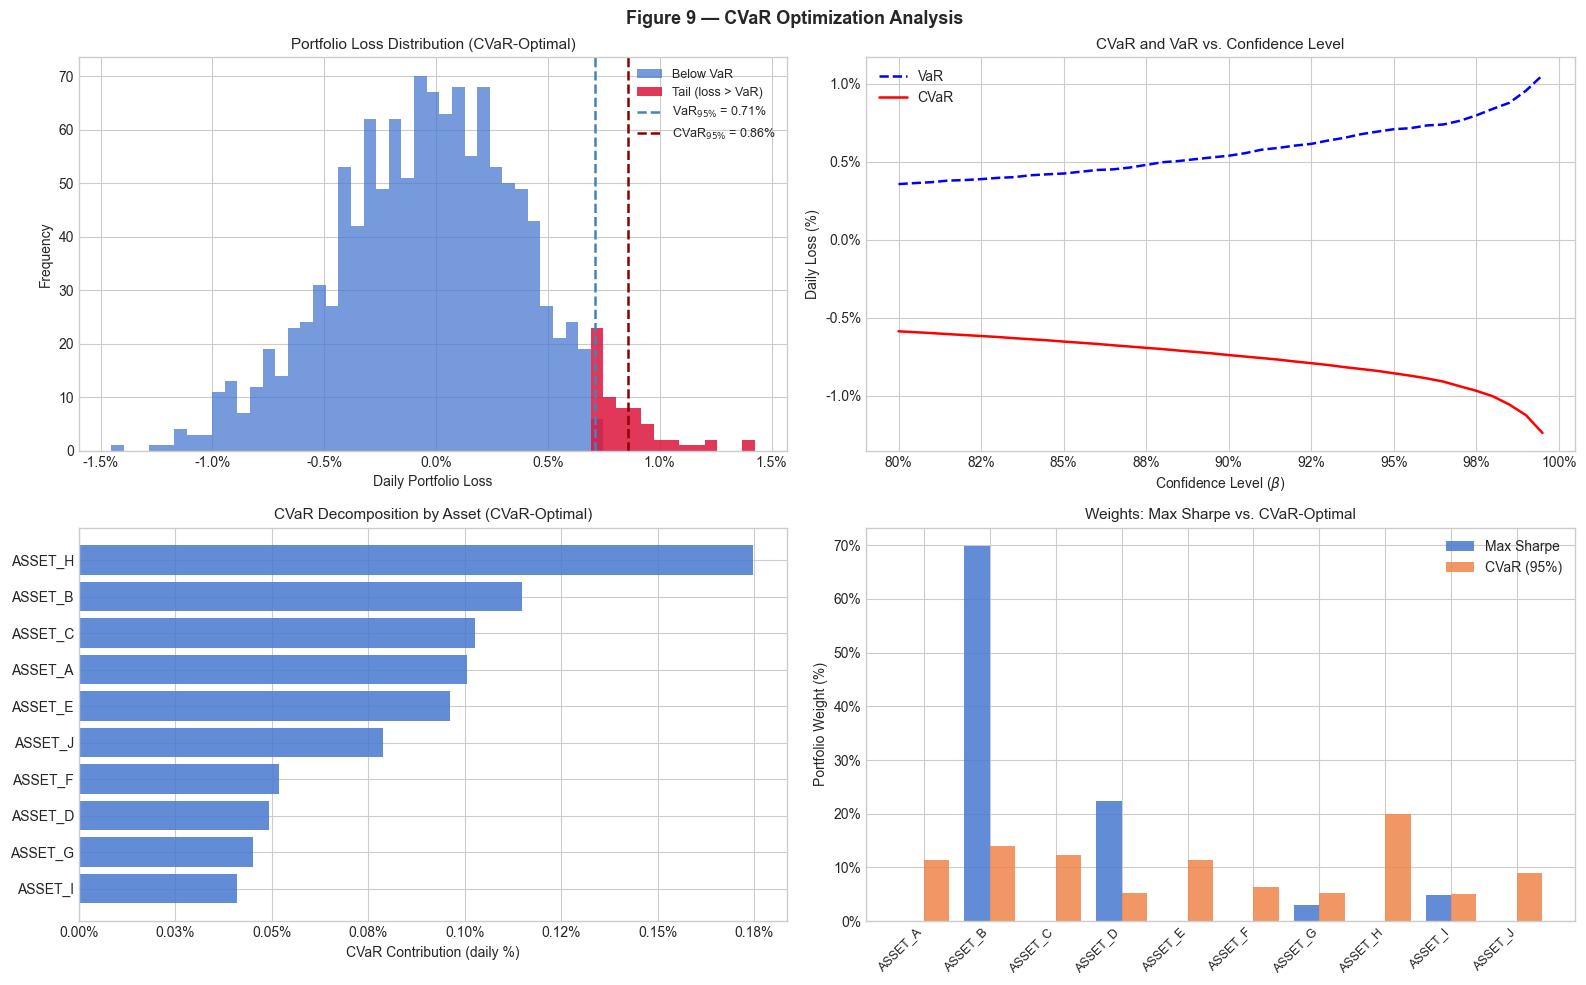

In [15]:
# Figure 9 — CVaR optimization analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax_tl, ax_tr, ax_bl, ax_br = axes.flat

# Top-left — Loss distribution histogram
losses = cvar_opt.scenario_losses_
var_95  = cvar_opt.var_
cvar_95 = cvar_opt.cvar_
bins    = np.linspace(losses.min(), losses.max(), 52)
mask_tail = losses >= var_95
ax_tl.hist(losses[~mask_tail], bins=bins, color=PALETTE[0],
           alpha=0.75, label="Below VaR")
ax_tl.hist(losses[mask_tail],  bins=bins, color="crimson",
           alpha=0.85, label=f"Tail (loss > VaR)")
ax_tl.axvline(var_95,  color="steelblue", linestyle="--", linewidth=1.8,
              label=f"VaR$_{{95\\%}}$ = {var_95:.2%}")
ax_tl.axvline(cvar_95, color="darkred",   linestyle="--", linewidth=1.8,
              label=f"CVaR$_{{95\\%}}$ = {cvar_95:.2%}")
ax_tl.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1%}"))
ax_tl.set_title("Portfolio Loss Distribution (CVaR-Optimal)", fontsize=11)
ax_tl.set_xlabel("Daily Portfolio Loss")
ax_tl.set_ylabel("Frequency")
ax_tl.legend(fontsize=9)

# Top-right — CVaR and VaR as a function of beta
betas  = np.linspace(0.80, 0.995, 40)
cvars_ = [cvar_opt.var_at_confidence(b) + 0.0 for b in betas]   # approximate
# Re-compute CVaR properly at each beta using scenario losses
var_curve  = np.array([float(-np.quantile(-losses, 1 - b)) for b in betas])
cvar_curve = np.array([
    float(-losses[losses >= -np.quantile(-losses, 1 - b)].mean())
    if np.any(losses >= -np.quantile(-losses, 1 - b)) else var_curve[i]
    for i, b in enumerate(betas)
])
ax_tr.plot(betas, var_curve  * 100, "b--",  linewidth=1.8, label="VaR")
ax_tr.plot(betas, cvar_curve * 100, "r-",   linewidth=1.8, label="CVaR")
ax_tr.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax_tr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax_tr.set_title("CVaR and VaR vs. Confidence Level", fontsize=11)
ax_tr.set_xlabel("Confidence Level ($\\beta$)")
ax_tr.set_ylabel("Daily Loss (%)")
ax_tr.legend()

# Bottom-left — CVaR decomposition by asset
sorted_decomp = cvar_decomp.sort_values(ascending=True)
ax_bl.barh(sorted_decomp.index, sorted_decomp.values * 100,
           color=PALETTE[0], alpha=0.85)
ax_bl.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax_bl.set_title("CVaR Decomposition by Asset (CVaR-Optimal)", fontsize=11)
ax_bl.set_xlabel("CVaR Contribution (daily %)")

# Bottom-right — Weight comparison: Max Sharpe vs CVaR
x      = np.arange(N_ASSETS)
width2 = 0.38
ax_br.bar(x - width2 / 2, w_max_sharpe.values * 100, width2,
          label="Max Sharpe", color=PALETTE[0], alpha=0.85)
ax_br.bar(x + width2 / 2, w_cvar.values * 100,       width2,
          label="CVaR (95%)",  color=PALETTE[1], alpha=0.85)
ax_br.set_xticks(x)
ax_br.set_xticklabels(TICKERS, rotation=45, ha="right", fontsize=9)
ax_br.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_br.set_title("Weights: Max Sharpe vs. CVaR-Optimal", fontsize=11)
ax_br.set_ylabel("Portfolio Weight (%)")
ax_br.legend()

fig.suptitle("Figure 9 — CVaR Optimization Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_09_cvar_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 7 — Walk-Forward Backtest

The walk-forward methodology avoids look-ahead bias by strictly separating
the estimation window from the evaluation window.

At each rebalancing date $t$:
1. Estimate all model parameters on the lookback window $[t - L, t)$, $L = 252$.
2. Solve the optimization problem and obtain target weights $\mathbf{w}_t^*$.
3. Apply a proportional shrinkage turnover constraint if specified.
4. Deduct transaction costs: $\text{TC} = c_{\text{prop}} \sum_i |\Delta w_i|$.
5. Hold until the next rebalancing date, allowing weights to drift with prices.

**Weight drift between rebalances:**
$$w_i(t) = \frac{w_i(t_0) \prod_{s=t_0+1}^{t}(1 + r_{i,s})}{\sum_j w_j(t_0)\prod_{s=t_0+1}^{t}(1+r_{j,s})}$$

**Transaction cost model:**
$$\text{TC}(\Delta\mathbf{w}) = c_{\text{prop}}\sum_i |\Delta w_i| + c_{\text{impact}}\sum_i\sqrt{|\Delta w_i|}$$
$$\text{One-way turnover} = \tfrac{1}{2}\sum_i |\Delta w_i|$$

**Four strategies are backtested:**
1. **Max Sharpe (BL + LW):** Black-Litterman returns (equal-weight prior, no views) + Ledoit-Wolf covariance.
2. **Min Volatility (Sample):** Historical mean returns + sample covariance.
3. **Risk Parity (EWM):** EWM covariance (span=60).
4. **CVaR Optimizer:** Direct CVaR minimization on window returns.

In [16]:
from quantopt.backtest.engine import WalkForwardBacktester, BacktestConfig, TransactionCostModel
from quantopt.returns.estimators import MeanHistoricalReturn, BlackLittermanReturn
from quantopt.risk.covariance import (
    SampleCovariance, EWMCovariance, LedoitWolfCovariance,
)
from quantopt.optimization.efficient_frontier import EfficientFrontier
from quantopt.optimization.risk_parity import RiskParity
from quantopt.optimization.cvar_optimizer import CVaROptimizer


def factory_max_sharpe(window_returns: pd.DataFrame):
    """BL returns (no active views) + LW covariance → Max Sharpe."""
    n  = len(window_returns.columns)
    mc = pd.Series(np.ones(n) / n, index=window_returns.columns)
    bl = BlackLittermanReturn(
        market_caps=mc, risk_aversion=2.5, tau=0.05,
    ).fit(window_returns)
    lw = LedoitWolfCovariance().fit(window_returns)
    return EfficientFrontier(mu=bl.expected_returns(), Sigma=lw.covariance())


def factory_min_vol(window_returns: pd.DataFrame):
    """Historical mean + sample covariance → Min Volatility."""
    mu_    = MeanHistoricalReturn().fit(window_returns).expected_returns()
    Sigma_ = SampleCovariance().fit(window_returns).covariance()
    ef     = EfficientFrontier(mu=mu_, Sigma=Sigma_)
    ef.optimize = ef.min_volatility  # override default max_sharpe
    return ef


def factory_risk_parity(window_returns: pd.DataFrame):
    """EWM covariance → ERC."""
    Sigma_ = EWMCovariance(span=60).fit(window_returns).covariance()
    return RiskParity(Sigma=Sigma_)


def factory_cvar(window_returns: pd.DataFrame):
    """Direct CVaR minimization (beta=0.95)."""
    return CVaROptimizer(returns=window_returns, beta=0.95)


config = BacktestConfig(
    lookback_days     = 252,
    rebalance_freq    = "M",
    transaction_cost  = TransactionCostModel(proportional=0.0010),
    max_turnover      = None,
    min_weight_threshold = 1e-4,
)

strategies = {
    "Max Sharpe (BL+LW)" : factory_max_sharpe,
    "Min Volatility"     : factory_min_vol,
    "Risk Parity (EWM)"  : factory_risk_parity,
    "CVaR Optimizer"     : factory_cvar,
}

results = {}
for name, factory in strategies.items():
    print(f"Running backtest: {name} ...", end=" ", flush=True)
    bt = WalkForwardBacktester(
        prices=prices, optimizer_factory=factory, config=config,
    )
    results[name] = bt.run()
    print("done.")

print("\nAll backtests complete.")

Running backtest: Max Sharpe (BL+LW) ... 

done.
Running backtest: Min Volatility ... 

done.
Running backtest: Risk Parity (EWM) ... 

done.
Running backtest: CVaR Optimizer ... 

done.

All backtests complete.


In [17]:
from quantopt.analytics.performance import (
    drawdown_series, performance_summary,
    annualized_return, annualized_volatility, sharpe_ratio, max_drawdown,
    cvar_historical,
)

# Build NAV series (starting at 1.0)
navs = {}
for name, res in results.items():
    nav = (1.0 + res.portfolio_returns).cumprod()
    nav = nav / nav.iloc[0]   # normalise to 1.0 at start
    navs[name] = nav

# Performance summary for all strategies
summary_rows = {}
for name, res in results.items():
    r = res.portfolio_returns
    summary_rows[name] = {
        "Ann. Return" : annualized_return(r),
        "Ann. Vol"    : annualized_volatility(r),
        "Sharpe"      : sharpe_ratio(r),
        "Max DD"      : max_drawdown(r),
        "CVaR 95%"    : cvar_historical(r, confidence=0.95),
    }

perf_df = pd.DataFrame(summary_rows).T
print(perf_df.applymap(lambda v: f"{v:.2%}" if abs(v) < 10 else f"{v:.3f}"))

                   Ann. Return Ann. Vol   Sharpe  Max DD CVaR 95%
Max Sharpe (BL+LW)      12.28%    7.68%  159.83%  -7.70%    0.91%
Min Volatility           9.56%    6.94%  137.71%  -8.63%    0.85%
Risk Parity (EWM)       10.88%    7.41%  146.79%  -9.10%    0.88%
CVaR Optimizer           8.04%    7.31%  109.97%  -9.81%    0.90%


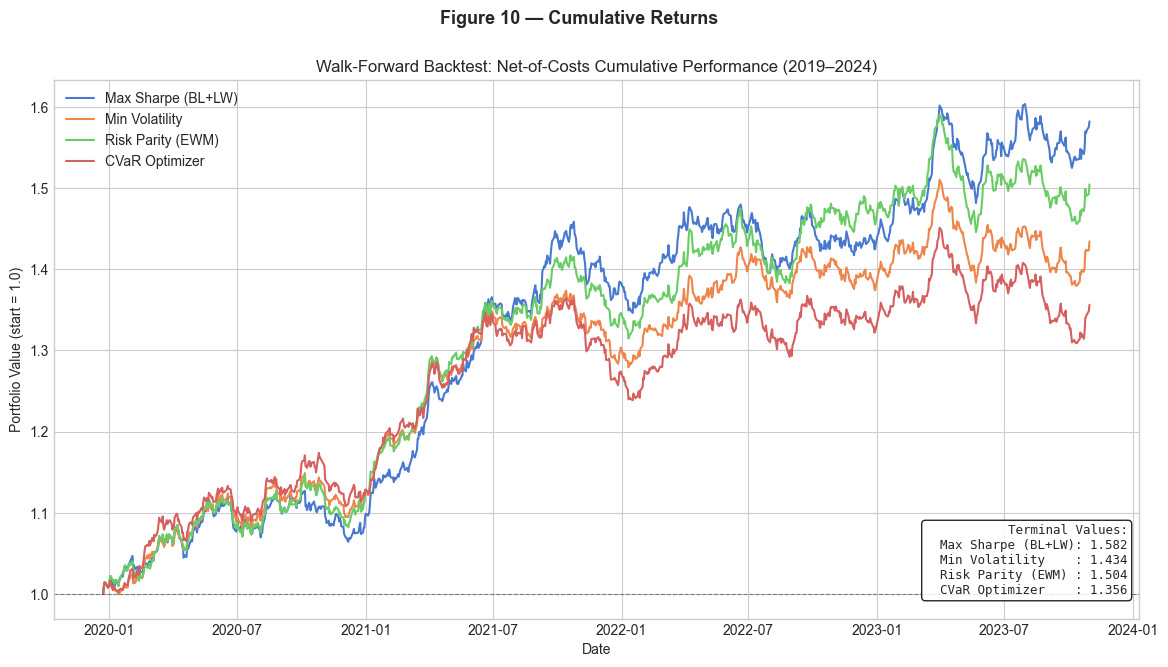

In [18]:
# Figure 10 — Cumulative returns
strat_colors = {name: PALETTE[i] for i, name in enumerate(strategies)}

fig, ax = plt.subplots(figsize=(14, 7))

# Shade drawdowns > 10% for best-performing strategy
best_name = perf_df["Sharpe"].idxmax()
best_dd   = drawdown_series(results[best_name].portfolio_returns)
crisis_mask = best_dd < -0.10
if crisis_mask.any():
    # Find contiguous regions
    in_crisis = False
    start_idx = None
    for date, flag in crisis_mask.items():
        if flag and not in_crisis:
            in_crisis = True
            start_idx = date
        elif not flag and in_crisis:
            in_crisis = False
            ax.axvspan(start_idx, date, alpha=0.15, color="grey")
    if in_crisis:
        ax.axvspan(start_idx, crisis_mask.index[-1], alpha=0.15, color="grey")

for name, nav in navs.items():
    ax.plot(nav.index, nav.values, label=name,
            color=strat_colors[name], linewidth=1.5)

# Terminal-value text box
tv_text = "Terminal Values:\n" + "\n".join(
    f"  {name[:18]:<18}: {nav.iloc[-1]:.3f}"
    for name, nav in navs.items()
)
ax.text(0.99, 0.04, tv_text, transform=ax.transAxes,
        fontsize=9, verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        family="monospace")

ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title(
    "Walk-Forward Backtest: Net-of-Costs Cumulative Performance (2019–2024)",
    fontsize=12,
)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (start = 1.0)")
ax.legend(loc="upper left", fontsize=10)

fig.suptitle("Figure 10 — Cumulative Returns", fontsize=13, fontweight="bold")
fig.savefig("../docs/figures/figure_10_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()

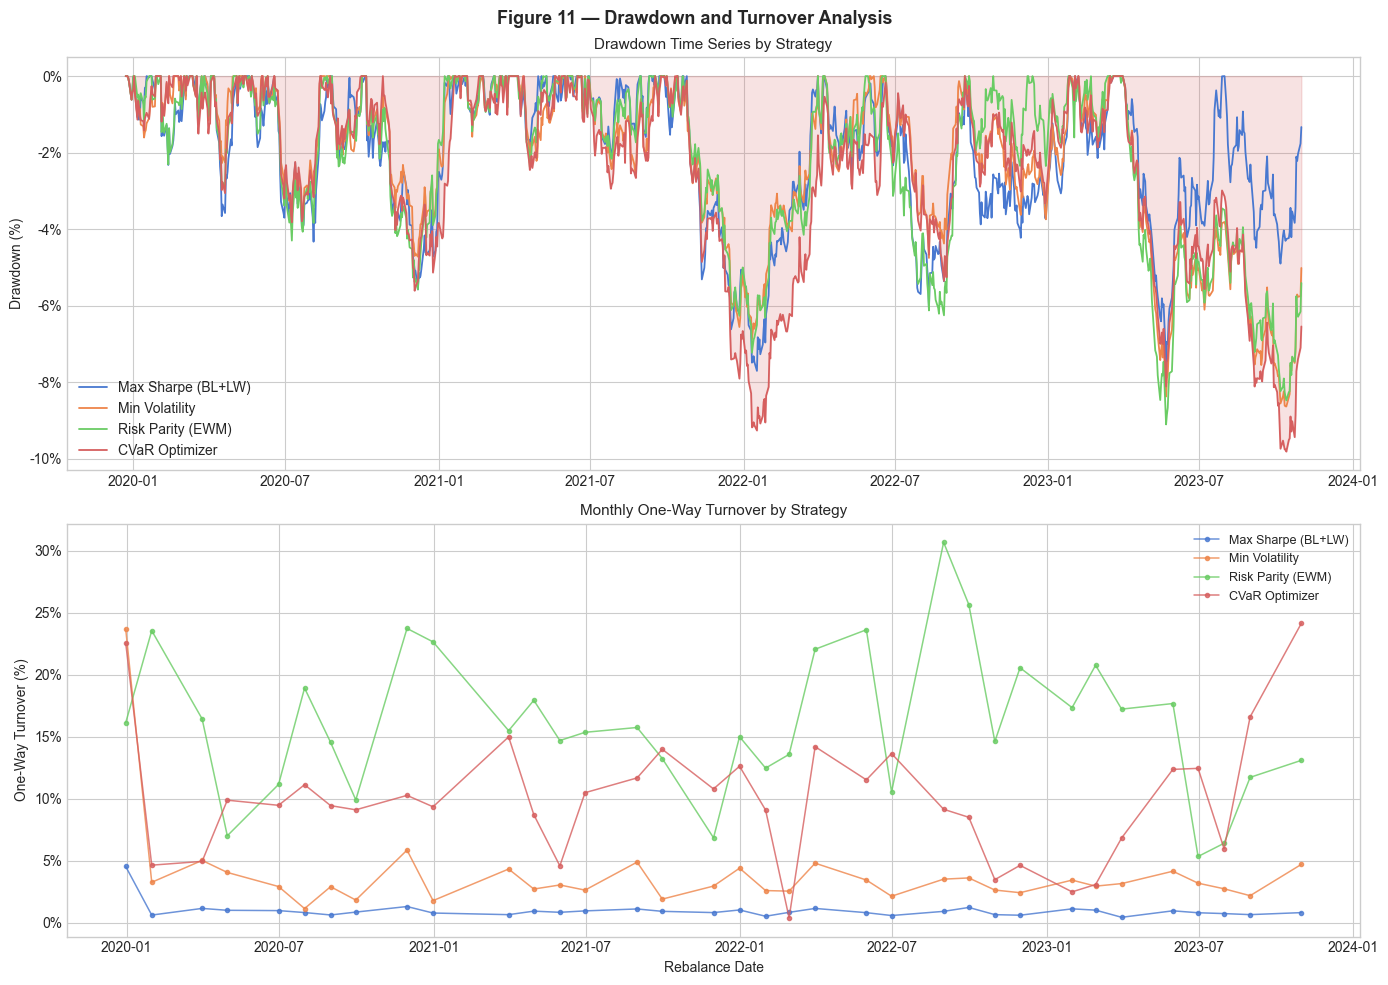

In [19]:
# Figure 11 — Drawdown analysis and turnover
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Panel 1 — Drawdown time series
worst_name = perf_df["Max DD"].idxmin()
for name, res in results.items():
    dd = drawdown_series(res.portfolio_returns) * 100
    if name == worst_name:
        ax_top.fill_between(dd.index, dd.values, 0,
                             alpha=0.18, color=strat_colors[name])
    ax_top.plot(dd.index, dd.values, label=name,
                color=strat_colors[name], linewidth=1.3)

ax_top.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_top.set_title("Drawdown Time Series by Strategy", fontsize=11)
ax_top.set_ylabel("Drawdown (%)")
ax_top.legend(fontsize=10)

# Panel 2 — Monthly turnover
for name, res in results.items():
    to = res.turnover_history * 100
    ax_bot.plot(to.index, to.values, "o-", label=name,
                color=strat_colors[name], linewidth=1.1, markersize=3, alpha=0.8)
ax_bot.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_bot.set_title("Monthly One-Way Turnover by Strategy", fontsize=11)
ax_bot.set_xlabel("Rebalance Date")
ax_bot.set_ylabel("One-Way Turnover (%)")
ax_bot.legend(fontsize=9)

fig.suptitle("Figure 11 — Drawdown and Turnover Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_11_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

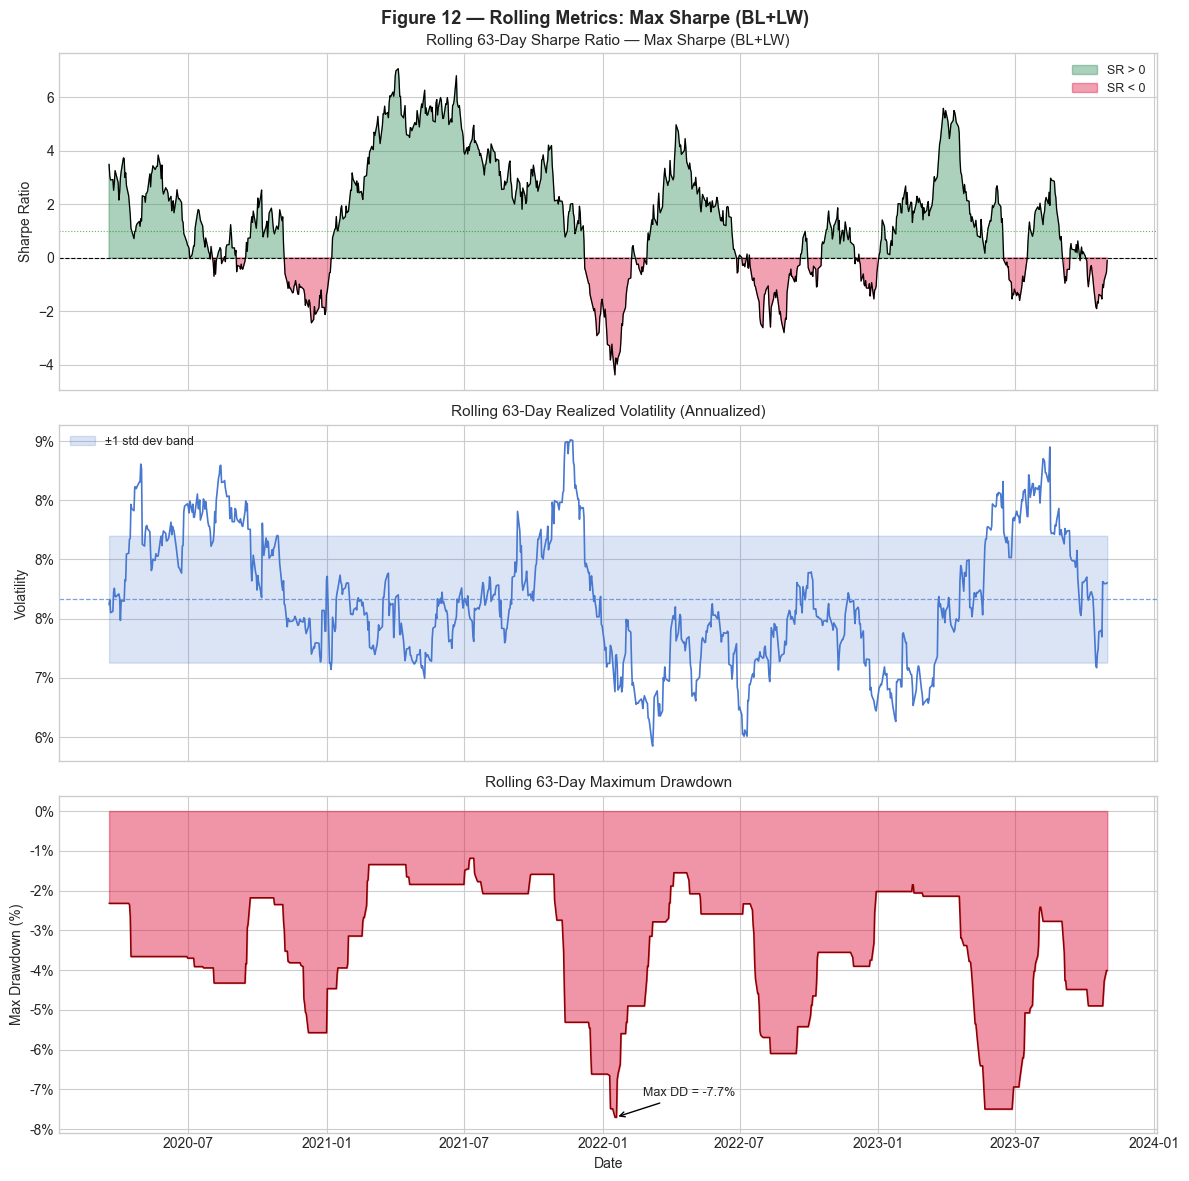

In [20]:
from quantopt.analytics.performance import rolling_metrics

# Figure 12 — Rolling performance metrics for best strategy
best_ret  = results[best_name].portfolio_returns
roll_m    = rolling_metrics(best_ret, window=63)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Panel 1 — Rolling Sharpe
sr_vals = roll_m["sharpe"].dropna()
ax1.fill_between(sr_vals.index, 0, sr_vals.values,
                  where=sr_vals.values >= 0, alpha=0.4, color="seagreen", label="SR > 0")
ax1.fill_between(sr_vals.index, 0, sr_vals.values,
                  where=sr_vals.values < 0,  alpha=0.4, color="crimson",  label="SR < 0")
ax1.plot(sr_vals.index, sr_vals.values, color="black", linewidth=0.9)
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.axhline(1, color="green", linewidth=0.8, linestyle=":",  alpha=0.6)
ax1.set_title(f"Rolling 63-Day Sharpe Ratio — {best_name}", fontsize=11)
ax1.set_ylabel("Sharpe Ratio")
ax1.legend(fontsize=9)

# Panel 2 — Rolling volatility
rv_vals  = roll_m["volatility"].dropna()
rv_mean  = rv_vals.mean()
rv_std   = rv_vals.std()
ax2.plot(rv_vals.index, rv_vals.values * 100, color=PALETTE[0], linewidth=1.2)
ax2.fill_between(
    rv_vals.index,
    (rv_mean - rv_std) * 100,
    (rv_mean + rv_std) * 100,
    alpha=0.2, color=PALETTE[0], label="±1 std dev band",
)
ax2.axhline(rv_mean * 100, color=PALETTE[0], linewidth=0.9, linestyle="--", alpha=0.7)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax2.set_title("Rolling 63-Day Realized Volatility (Annualized)", fontsize=11)
ax2.set_ylabel("Volatility")
ax2.legend(fontsize=9)

# Panel 3 — Rolling max drawdown
mdd_vals = roll_m["max_drawdown"].dropna() * 100
ax3.fill_between(mdd_vals.index, mdd_vals.values, 0, alpha=0.45, color="crimson")
ax3.plot(mdd_vals.index, mdd_vals.values, color="darkred", linewidth=1.1)
global_min_date = mdd_vals.idxmin()
global_min_val  = mdd_vals.min()
ax3.annotate(
    f"Max DD = {global_min_val:.1f}%",
    xy=(global_min_date, global_min_val),
    xytext=(20, 15), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9,
)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax3.set_title("Rolling 63-Day Maximum Drawdown", fontsize=11)
ax3.set_xlabel("Date")
ax3.set_ylabel("Max Drawdown (%)")

fig.suptitle(f"Figure 12 — Rolling Metrics: {best_name}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_12_rolling_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

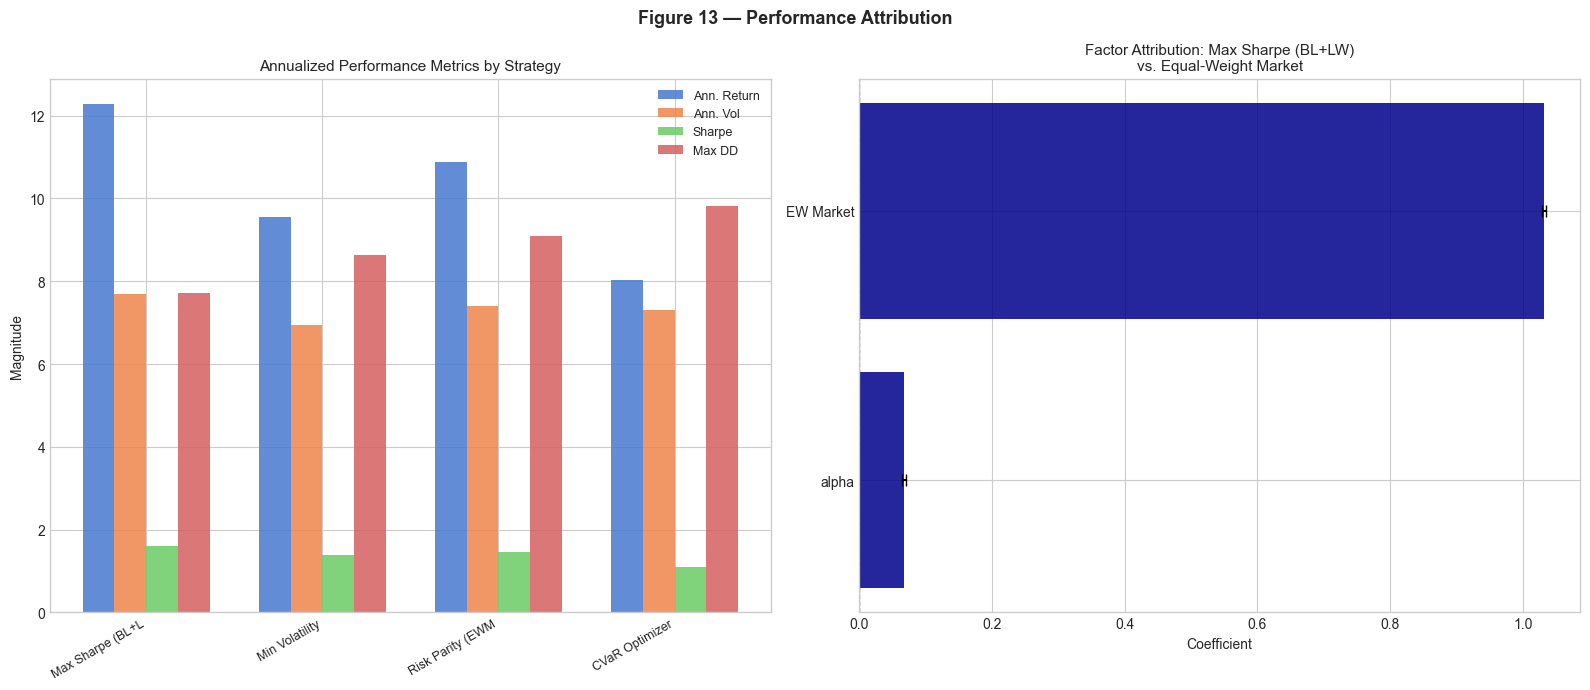


Factor Attribution Table:
           coefficient    t_stat  p_value
alpha           0.0673   20.2500      0.0
EW Market       1.0319  365.6878      0.0


In [21]:
from quantopt.analytics.performance import factor_attribution

# Figure 13 — Performance attribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1 — Grouped metrics bar chart
metric_cols  = ["Ann. Return", "Ann. Vol", "Sharpe", "Max DD"]
metric_scale = [100, 100, 1, 100]   # multiply for display
metric_fmt   = ["%", "%", "×", "%"]
n_strategies = len(strategies)
x3           = np.arange(n_strategies)
n_metrics    = len(metric_cols)
w_bar        = 0.18

for m_idx, (metric, scale) in enumerate(zip(metric_cols, metric_scale)):
    vals  = perf_df[metric].values * scale
    color = PALETTE[m_idx]
    ax1.bar(x3 + m_idx * w_bar, np.abs(vals), w_bar,
            label=metric, color=color, alpha=0.85)

ax1.set_xticks(x3 + (n_metrics - 1) / 2 * w_bar)
ax1.set_xticklabels([n[:16] for n in list(strategies.keys())],
                    rotation=30, ha="right", fontsize=9)
ax1.set_title("Annualized Performance Metrics by Strategy", fontsize=11)
ax1.set_ylabel("Magnitude")
ax1.legend(fontsize=9)

# Panel 2 — Factor attribution (best strategy vs equal-weight)
ew_returns = returns.mean(axis=1)
ew_returns = ew_returns.reindex(results[best_name].portfolio_returns.index)

# Use equal-weight market as single factor
factor_df = pd.DataFrame({"EW Market": ew_returns})
attr = factor_attribution(
    portfolio_returns=results[best_name].portfolio_returns,
    factor_returns=factor_df,
)

coefs = attr["coefficient"]
se    = attr["coefficient"] / attr["t_stat"].replace(0, np.nan).fillna(1e6)
colors_attr = ["darkblue" if c > 0 else "crimson" for c in coefs]
ax2.barh(coefs.index, coefs.values, xerr=se.abs().values,
         color=colors_attr, alpha=0.85, capsize=4)
ax2.axvline(0, color="black", linewidth=0.9, linestyle="--")
ax2.set_title(f"Factor Attribution: {best_name}\nvs. Equal-Weight Market", fontsize=11)
ax2.set_xlabel("Coefficient")

fig.suptitle("Figure 13 — Performance Attribution", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_13_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFactor Attribution Table:")
print(attr.round(4).to_string())

---
## Section 8 — Risk Report and Performance Summary

The `risk_report()` function computes a comprehensive single-portfolio risk
tear sheet: annualized volatility, diversification ratio, Herfindahl-Hirschman
Index, parametric VaR and CVaR, and the top contributors to marginal and
component risk.

The `performance_summary()` function produces a full backtest tear sheet:
annualized return and volatility, Sharpe, Sortino, Calmar, Omega, max drawdown,
historical VaR and CVaR, skewness, and excess kurtosis.

In [22]:
from quantopt.risk.metrics import risk_report

# Risk report for the Max Sharpe portfolio
rr = risk_report(
    weights=w_max_sharpe,
    Sigma=Sigma_lw,
)
print("=" * 55)
print("Risk Report — Max Sharpe Portfolio")
print("=" * 55)
print(rr.to_string())
print()

# Full performance tear sheet for each backtest strategy
perf_summaries = {}
for name, res in results.items():
    perf_summaries[name] = performance_summary(
        returns=res.portfolio_returns,
        risk_free_rate=0.02,
        name=name[:20],
    )

full_summary = pd.concat(perf_summaries.values(), axis=1)
print("=" * 90)
print("Full Performance Summary — All Strategies")
print("=" * 90)
print(full_summary.to_string())

Risk Report — Max Sharpe Portfolio
                                                                    Value
Volatility (Ann.)                                                  19.75%
Diversification Ratio                                                1.57
Concentration HHI                                                  0.5405
Effective N                                                           1.9
Parametric VaR (95%)                                                2.05%
Parametric CVaR (95%)                                               2.57%
Top 3 MRC              ASSET_B (27.13%), ASSET_G (3.95%), ASSET_A (3.14%)
Top 3 PRC                 ASSET_B (95.9%), ASSET_D (3.3%), ASSET_G (0.6%)

Full Performance Summary — All Strategies
                      Max Sharpe (BL+LW) Min Volatility Risk Parity (EWM) CVaR Optimizer
Annualized Return                 12.28%          9.56%            10.88%          8.04%
Annualized Volatility              7.68%          6.94%             7.41%     

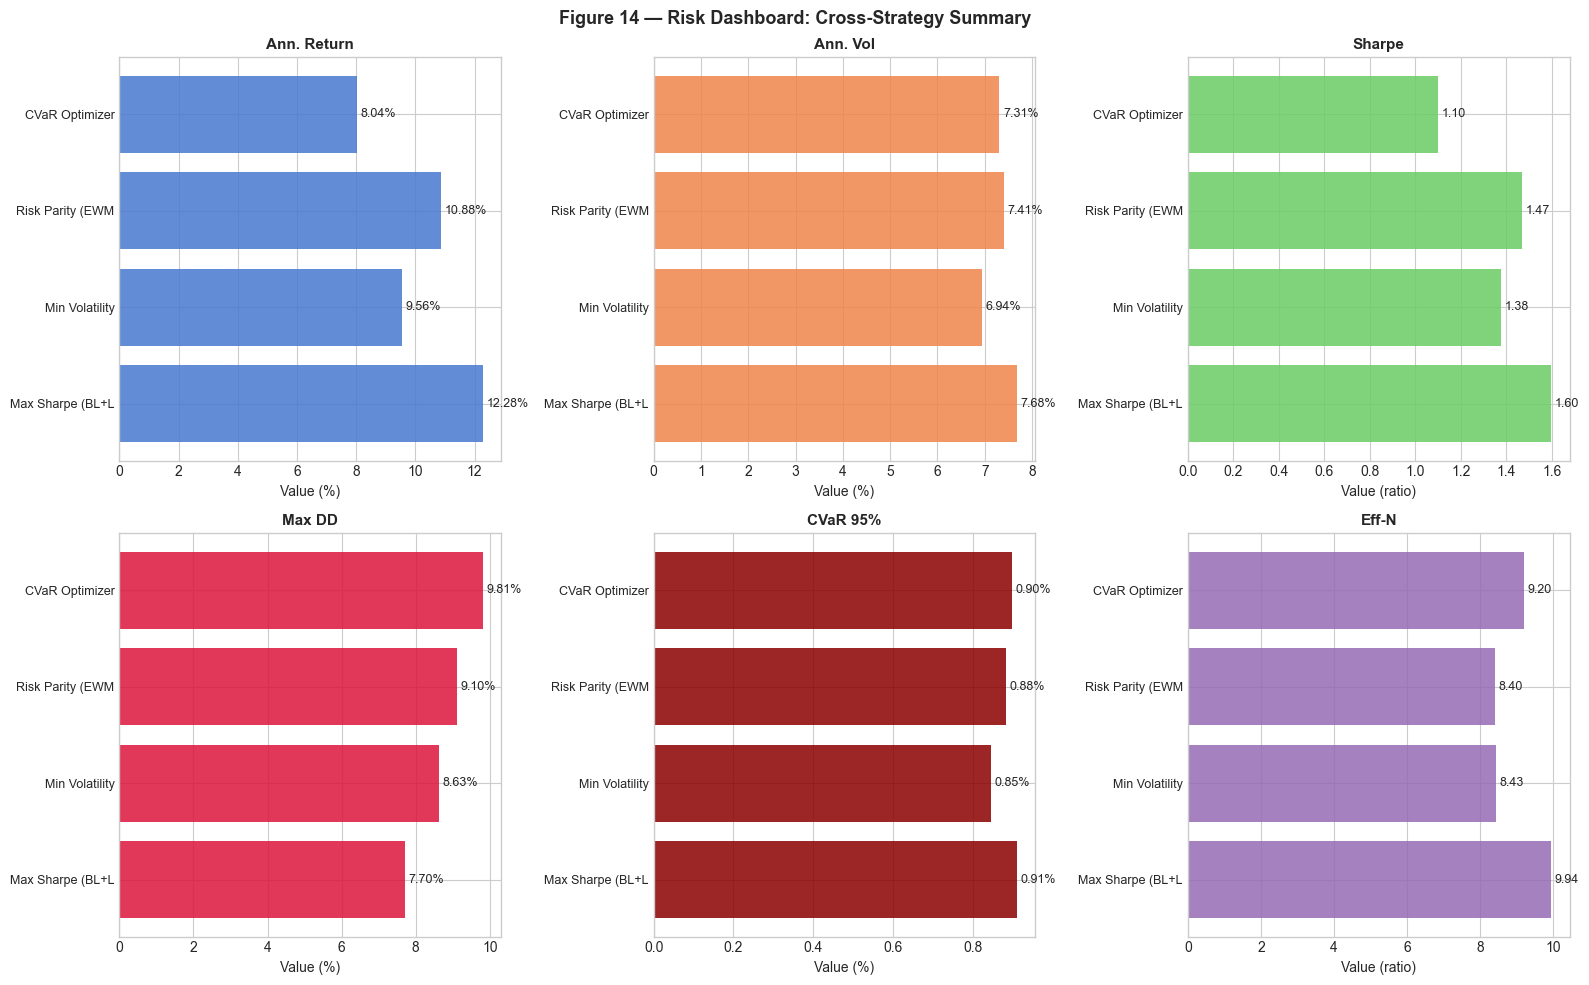

In [23]:
# Figure 14 — Risk dashboard (2×3 summary grid)
metrics_to_plot = [
    ("Ann. Return",  False, PALETTE[0], "%"),
    ("Ann. Vol",     False, PALETTE[1], "%"),
    ("Sharpe",       False, PALETTE[2], ""),
    ("Max DD",       True,  "crimson",  "%"),
    ("CVaR 95%",     True,  "darkred",  "%"),
    ("Eff-N",        False, PALETTE[4], ""),
]

# Add effective N
# We need the realized weights at the last rebalance date for each strategy
from quantopt.risk.metrics import effective_n as eff_n_fn
eff_n_vals = {}
for name, res in results.items():
    last_w = res.weights_history.iloc[-1]
    last_w = last_w[last_w > 0]
    last_w = last_w / last_w.sum()
    eff_n_vals[name] = eff_n_fn(last_w)

perf_df["Eff-N"] = pd.Series(eff_n_vals)
perf_df["CVaR 95%"] = pd.Series(
    {name: cvar_historical(res.portfolio_returns, 0.95)
     for name, res in results.items()}
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
strat_names_short = [n[:16] for n in list(strategies.keys())]

for ax, (metric, is_loss, color, suffix) in zip(axes.flat, metrics_to_plot):
    vals = perf_df[metric].values
    display_vals = np.abs(vals) * (100 if suffix == "%" else 1)
    bars = ax.barh(strat_names_short, display_vals, color=color, alpha=0.85)
    for i, v in enumerate(display_vals):
        ax.text(v + display_vals.max() * 0.01, i,
                f"{v:.2f}{suffix}", va="center", fontsize=9)
    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.set_xlabel(f"Value ({suffix or 'ratio'})")
    ax.tick_params(axis="y", labelsize=9)

fig.suptitle("Figure 14 — Risk Dashboard: Cross-Strategy Summary",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../docs/figures/figure_14_risk_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 9 — Sensitivity Analysis: L2 Regularization

The maximum Sharpe portfolio is highly sensitive to the input expected returns.
Merton (1980) demonstrated that estimation error in $\boldsymbol{\mu}$ propagates
approximately $N$ times more strongly into portfolio weights than equivalent
estimation error in $\boldsymbol{\Sigma}$. This motivates the L2 regularization
penalty $\gamma\mathbf{w}^\top\mathbf{w}$, which smooths the solution toward the
equal-weight portfolio.

As $\gamma \to 0$, the optimizer returns the unconstrained tangency portfolio;
as $\gamma \to \infty$, the optimizer returns $\mathbf{w} = \mathbf{1}/N$
(minimum HHI). The two figures below illustrate the Sharpe-concentration
tradeoff across a grid of $\gamma$ values.

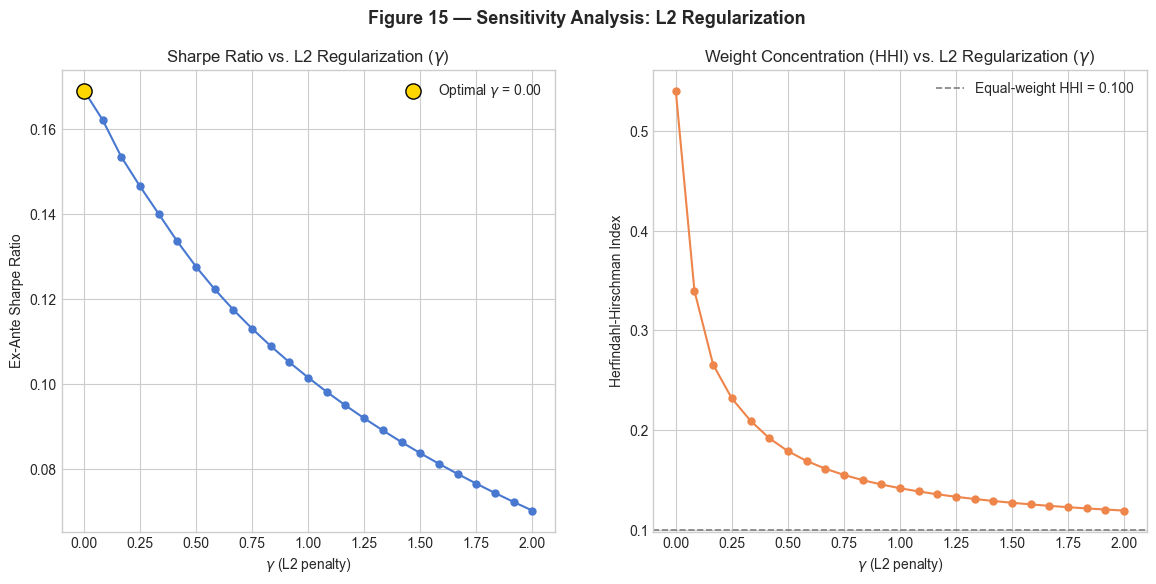

Unconstrained (gamma=0):  Sharpe=0.169, HHI=0.5405
Optimal gamma=0.00: Sharpe=0.169, HHI=0.5405
Fully regularized (gamma=2): Sharpe=0.070, HHI=0.1192


In [24]:
# Figure 15 — Sensitivity analysis
gammas    = np.linspace(0, 2.0, 25)
sr_gamma  = []
hhi_gamma = []

for g in gammas:
    try:
        ef_g = EfficientFrontier(mu=mu_bl, Sigma=Sigma_lw, l2_gamma=g)
        w_g  = ef_g.max_sharpe(risk_free_rate=0.02)
        _, _, sr_g = ef_g.portfolio_performance(mu=mu_bl, Sigma=Sigma_lw, risk_free_rate=0.02)
        sr_gamma.append(sr_g)
        hhi_gamma.append(concentration_hhi(w_g))
    except Exception:
        sr_gamma.append(np.nan)
        hhi_gamma.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1 — Sharpe vs gamma
ax1.plot(gammas, sr_gamma, "o-", color=PALETTE[0], markersize=5)
opt_idx = int(np.nanargmax(sr_gamma))
ax1.scatter([gammas[opt_idx]], [sr_gamma[opt_idx]],
            s=120, color="gold", edgecolors="black", zorder=6,
            label=f"Optimal $\\gamma$ = {gammas[opt_idx]:.2f}")
ax1.set_title("Sharpe Ratio vs. L2 Regularization ($\\gamma$)", fontsize=12)
ax1.set_xlabel("$\\gamma$ (L2 penalty)")
ax1.set_ylabel("Ex-Ante Sharpe Ratio")
ax1.legend()

# Panel 2 — HHI vs gamma
hhi_erc = 1.0 / N_ASSETS
ax2.plot(gammas, hhi_gamma, "o-", color=PALETTE[1], markersize=5)
ax2.axhline(hhi_erc, color="grey", linestyle="--", linewidth=1.2,
            label=f"Equal-weight HHI = {hhi_erc:.3f}")
ax2.set_title("Weight Concentration (HHI) vs. L2 Regularization ($\\gamma$)", fontsize=12)
ax2.set_xlabel("$\\gamma$ (L2 penalty)")
ax2.set_ylabel("Herfindahl-Hirschman Index")
ax2.legend()

fig.suptitle("Figure 15 — Sensitivity Analysis: L2 Regularization",
             fontsize=13, fontweight="bold")
fig.savefig("../docs/figures/figure_15_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Unconstrained (gamma=0):  Sharpe={sr_gamma[0]:.3f}, HHI={hhi_gamma[0]:.4f}")
print(f"Optimal gamma={gammas[opt_idx]:.2f}: Sharpe={sr_gamma[opt_idx]:.3f}, HHI={hhi_gamma[opt_idx]:.4f}")
print(f"Fully regularized (gamma=2): Sharpe={sr_gamma[-1]:.3f}, HHI={hhi_gamma[-1]:.4f}")

In [25]:
print("All figures saved to ../docs/figures/")
import os
saved = sorted(os.listdir("../docs/figures/"))
for f in saved:
    print(f"  {f}")

All figures saved to ../docs/figures/
  figure_01_price_series.png
  figure_02_return_statistics.png
  figure_03_return_estimators.png
  figure_04_covariance_comparison.png
  figure_05_covariance_diagnostics.png
  figure_06_efficient_frontier.png
  figure_07_optimal_weights.png
  figure_08_risk_parity.png
  figure_09_cvar_optimization.png
  figure_10_cumulative_returns.png
  figure_11_drawdown.png
  figure_12_rolling_metrics.png
  figure_13_attribution.png
  figure_14_risk_dashboard.png
  figure_15_sensitivity.png
